<div style="text-align: center; padding: 40px 0">

<p style="font-size: 16px; font-weight: normal; margin-bottom: 8px">Empirical Methods in Finance</p>

<h1 style="font-size: 28px; font-weight: bold; line-height: 1.4; margin-bottom: 16px">
Oil Shocks, the Yield Curve and U.S. Equity Returns:<br>
Evidence from Weekly Data and Out-of-Sample Forecasting
</h1>


<p style="font-size: 14px; line-height: 1.8; font-weight: normal">
Matteo Piras (20806717)<br>
Marco D'Amico (25416579)<br>
Roberto Berardi (25419094)
</p>

</div>

In [58]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import random
import os
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

from IPython.display import display, HTML

## 1. Data 

We use the daily dataset covering WTI crude oil prices, S&P500 index levels and U.S. Treasury yields at the 2-year and 10-year maturities. The sample runs from January 1990 to March 2026.

In [59]:
# Random seed for reproducibility
random.seed(42)
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["MKL_NUM_THREADS"]        = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]    = "1"

np.random.seed(42)

# Load the dataset from Excel file
file_path = "data_hec_projet_1.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Daily",
    skiprows=6,
    header=0
)

# Keep only: date, oil, S&P500, 10Y and 2Y rates
df = df.iloc[:, [0, 1, 6, 10, 11]]
df.columns = ["date", "oil", "spx", "r10", "r2"]

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.sort_index()

print("Shape:", df.shape)
print("\nFirst rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Shape: (9442, 4)

First rows:
              oil     spx    r10     r2
date                                   
1990-01-02  22.89  359.69  7.930  7.875
1990-01-03  23.68  358.76  7.974  7.927
1990-01-04  23.41  355.67  7.972  7.910
1990-01-05  23.08  352.20  7.984  7.885
1990-01-08  21.62  353.79  8.012  7.893

Data types:
oil    float64
spx    float64
r10    float64
r2     float64
dtype: object
Date range: 1990-01-02 to 2026-03-11


## 2. Data Transformation 

Daily observations are resampled to weekly frequency using end-of-week (Friday) values. Log returns are computed for oil and the S&P500. The yield curve spread is defined as the difference between the 10-year and 2-year Treasury rates, and its first difference is taken as the working variable.

$$r_t = \ln(P_t) - \ln(P_{t-1}) \qquad spread_t = r10_t - r2_t \qquad \Delta spread_t = spread_t - spread_{t-1}$$

In [60]:
# Daily data to weekly frequency, taking the last observation of each week (Friday)
df_weekly = df.resample('W-FRI').last()

# Log returns for oil and S&P500
df_weekly['r_oil'] = np.log(df_weekly['oil']).diff()
df_weekly['r_spx'] = np.log(df_weekly['spx']).diff()

# Compute the 10Y-2Y yield curve spread and its weekly change
df_weekly['spread'] = df_weekly['r10'] - df_weekly['r2']
df_weekly['d_spread'] = df_weekly['spread'].diff()

df_weekly = df_weekly.dropna()

print("Weekly Dataframe shape:", df_weekly.shape)
print("\nFirst rows:")
display(df_weekly.head())

Weekly Dataframe shape: (1888, 8)

First rows:


,oil,spx,r10,r2,r_oil,r_spx,spread,d_spread
date,,,,,,,,
1990-01-12,22.13,339.93,8.096,7.938,-0.042032,-0.035459,0.158,0.059
1990-01-19,22.08,339.15,8.232,8.162,-0.002262,-0.002297,0.070,-0.088
1990-01-26,22.56,325.80,8.464,8.263,0.021506,-0.040159,0.201,0.131
1990-02-02,23.02,330.92,8.494,8.341,0.020185,0.015593,0.153,-0.048
1990-02-09,21.56,333.62,8.290,8.218,-0.065524,0.008126,0.072,-0.081


## 3. Time Series Visualization

The four panels show the full history of the working variables over the sample period. Visual inspection of the series is a preliminary step before formal statistical testing.

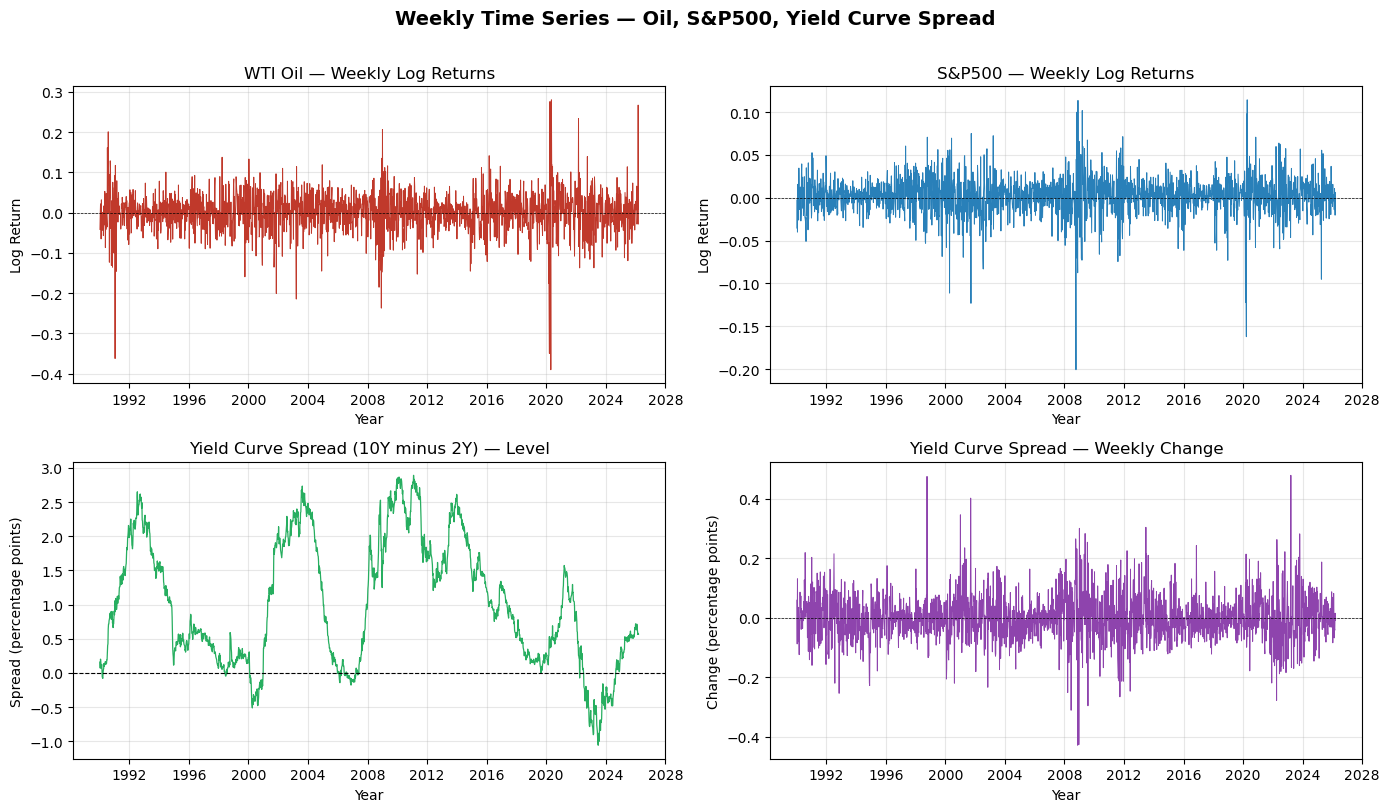

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Weekly Time Series — Oil, S&P500, Yield Curve Spread", 
             fontsize=14, fontweight="bold", y=1.01)

axes[0, 0].plot(df_weekly.index, df_weekly["r_oil"], 
                color="#c0392b", linewidth=0.7)
axes[0, 0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0, 0].set_title("WTI Oil — Weekly Log Returns")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Log Return")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df_weekly.index, df_weekly["r_spx"], 
                color="#2980b9", linewidth=0.7)
axes[0, 1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0, 1].set_title("S&P500 — Weekly Log Returns")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Log Return")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df_weekly.index, df_weekly["spread"], 
                color="#27ae60", linewidth=0.9)
axes[1, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1, 0].set_title("Yield Curve Spread (10Y minus 2Y) — Level")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Spread (percentage points)")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df_weekly.index, df_weekly["d_spread"], 
                color="#8e44ad", linewidth=0.7)
axes[1, 1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1, 1].set_title("Yield Curve Spread — Weekly Change")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Change (percentage points)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The charts display the two log return series and the yield curve spread in levels and first differences. Major episodes such as the 2008 financial crisis, the 2020 COVID shock and the 2022 rate hiking cycle are visible as spikes in all four panels.

## 4. Summary Statistics

We compute the first four moments of each series from scratch using direct summation formulas. Excess kurtosis is defined relative to the normal distribution.

$$\bar{x} = \frac{1}{n}\sum_{t=1}^{n} x_t \qquad s = \sqrt{\frac{1}{n-1}\sum_{t=1}^{n}(x_t-\bar{x})^2} \qquad \text{Skew} = \frac{m_3}{m_2^{3/2}} \qquad \text{Kurt} = \frac{m_4}{m_2^{2}} - 3$$

In [62]:
def compute_moments(series):
    x = series.dropna().to_numpy()
    n = len(x)
    
    mean_val = np.sum(x) / n
    deviations = x - mean_val
    
    # Standard deviation with n-1 for unbiased estimation
    std_val = np.sqrt(np.sum(deviations**2) / (n - 1))
    
    # Central moments for skewness and excess kurtosis
    m2 = np.sum(deviations**2) / n
    m3 = np.sum(deviations**3) / n
    m4 = np.sum(deviations**4) / n
    
    skew_val = m3 / (m2 ** 1.5)
    kurt_val = (m4 / (m2 ** 2)) - 3  # excess kurtosis relative to normal
    
    return {
        'Mean': mean_val,
        'Std Dev': std_val,
        'Skewness': skew_val,
        'Excess Kurtosis': kurt_val,
        'Minimum': np.min(x),
        'Maximum': np.max(x)
    }

vars_to_analyze = ['r_oil', 'r_spx', 'd_spread']
var_labels = {
    'r_oil': 'WTI Oil (Log Return)',
    'r_spx': 'S&P 500 (Log Return)',
    'd_spread': 'Spread Change (d_spread)'
}

results = {var_labels[v]: compute_moments(df_weekly[v]) for v in vars_to_analyze}
df_moments_table = pd.DataFrame.from_dict(results, orient='index')

print("Summary Statistics:")
display(df_moments_table.round(4))

Summary Statistics:


,Mean,Std Dev,Skewness,Excess Kurtosis,Minimum,Maximum
WTI Oil (Log Return),0.0007,0.0502,-0.6473,7.0654,-0.3904,0.2799
S&P 500 (Log Return),0.0016,0.0232,-0.7899,6.9448,-0.2008,0.1142
Spread Change (d_spread),0.0002,0.0802,0.3041,3.1832,-0.4285,0.4787


## 5. Normality Test — Jarque-Bera

The Jarque-Bera test checks whether skewness and excess kurtosis are jointly zero, as they would be under normality. The null hypothesis is that the series follows a normal distribution.

$$JB = \frac{n}{6}\left(S^2 + \frac{K^2}{4}\right) \sim \chi^2(2)$$

In [63]:
# Jarque-Bera test for normality on each series
jb_results = {}

for name, series in [("WTI Oil (Log Return)",       df_weekly["r_oil"]),
                     ("S&P 500 (Log Return)",        df_weekly["r_spx"]),
                     ("Spread Change (d_spread)",    df_weekly["d_spread"])]:
    
    jb_stat, jb_pval = stats.jarque_bera(series.dropna())
    jb_results[name] = {
        "JB Statistic"     : round(jb_stat, 2),
        "P-Value"          : round(jb_pval, 6),
        "Reject H0 at 5%?" : "YES" if jb_pval < 0.05 else "NO"
    }

jb_df = pd.DataFrame(jb_results).T

print("Jarque-Bera Normality Tests:")
jb_df

Jarque-Bera Normality Tests:


,JB Statistic,P-Value,Reject H0 at 5%?
WTI Oil (Log Return),4058.89,0.0,YES
S&P 500 (Log Return),3990.42,0.0,YES
Spread Change (d_spread),826.22,0.0,YES


The table reports the JB statistic and p-value for each series. A rejection of $H_0$ at the 5% level indicates significant departures from normality.

## 6. Autocorrelation Analysis

We plot the ACF for both the raw series and the squared series up to 20 lags. The squared series captures volatility clustering — the tendency for large moves to be followed by large moves. The shaded bands represent the 95% confidence interval under the white noise hypothesis.

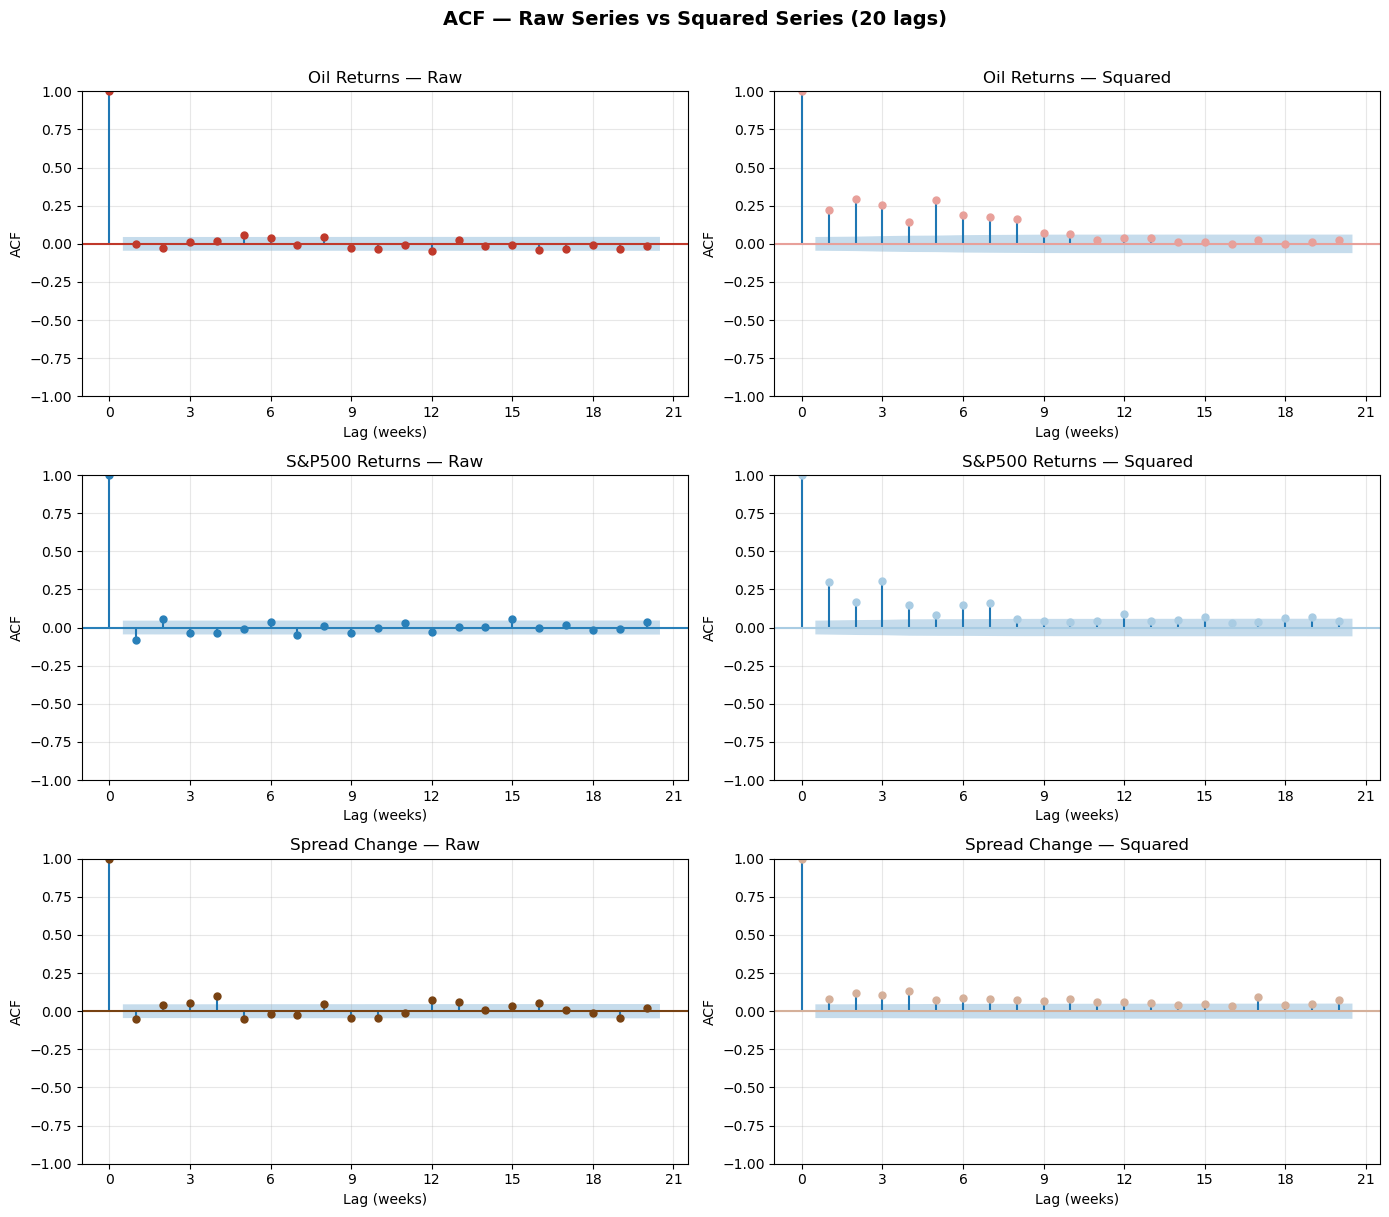

In [64]:
# ACF plots for raw and squared series ( squared series captures volatility clustering )
series_dict = {
    "Oil Returns"    : df_weekly["r_oil"],
    "S&P500 Returns" : df_weekly["r_spx"],
    "Spread Change"  : df_weekly["d_spread"]
}

colors = [
    ("#c0392b", "#e8a09a"),
    ("#2980b9", "#a9cce3"),
    ("#784212", "#d5b09a"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("ACF — Raw Series vs Squared Series (20 lags)", 
             fontsize=14, fontweight="bold", y=1.01)

for i, (name, series) in enumerate(series_dict.items()):

    plot_acf(series.dropna(), lags=20, alpha=0.05,
             ax=axes[i, 0], zero=True, color=colors[i][0])
    axes[i, 0].set_title(f"{name} — Raw")
    axes[i, 0].set_xlabel("Lag (weeks)")
    axes[i, 0].set_ylabel("ACF")
    axes[i, 0].xaxis.set_major_locator(plt.MultipleLocator(3))
    axes[i, 0].grid(True, alpha=0.3)

    plot_acf(series.dropna()**2, lags=20, alpha=0.05,
             ax=axes[i, 1], zero=True, color=colors[i][1])
    axes[i, 1].set_title(f"{name} — Squared")
    axes[i, 1].set_xlabel("Lag (weeks)")
    axes[i, 1].set_ylabel("ACF")
    axes[i, 1].xaxis.set_major_locator(plt.MultipleLocator(3))
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Left panels show the ACF of the raw series. Right panels show the ACF of the squared series. Bars exceeding the confidence bands indicate statistically significant autocorrelation at that lag.

## 7. Ljung-Box Test

The Ljung-Box test formally assesses whether the first $k$ autocorrelations are jointly equal to zero. It is applied to each series at lags 4, 8 and 12 weeks.

$$LB = n(n+2)\sum_{j=1}^{k}\frac{\hat{\rho}_j^2}{n-j} \sim \chi^2(k)$$

In [65]:
# Ljung-Box test at lags 4, 8, and 12 for each series and its squared transformation
lb_oil    = acorr_ljungbox(df_weekly["r_oil"].dropna(),    lags=[4, 8, 12], return_df=True)
lb_spx    = acorr_ljungbox(df_weekly["r_spx"].dropna(),    lags=[4, 8, 12], return_df=True)
lb_spread = acorr_ljungbox(df_weekly["d_spread"].dropna(), lags=[4, 8, 12], return_df=True)

lb_oil["Series"]    = "Oil Returns"
lb_spx["Series"]    = "S&P500 Returns"
lb_spread["Series"] = "Spread Change"

lb_all = pd.concat([lb_oil, lb_spx, lb_spread])
lb_all.index.name = "Lag"
lb_all = lb_all.reset_index()

lb_all = lb_all[["Series", "Lag", "lb_stat", "lb_pvalue"]]
lb_all.columns = ["Series", "Lag", "LB Statistic", "P-Value"]
lb_all["LB Statistic"] = lb_all["LB Statistic"].round(2)
lb_all["P-Value"]      = lb_all["P-Value"].round(4)
lb_all["Reject H0 at 5%?"] = lb_all["P-Value"].apply(
    lambda p: "YES" if p < 0.05 else "NO"
)

print("Ljung-Box Autocorrelation Tests:")
lb_all

Ljung-Box Autocorrelation Tests:


,Series,Lag,LB Statistic,P-Value,Reject H0 at 5%?
0,Oil Returns,4,2.74,0.6016,NO
1,Oil Returns,8,14.56,0.0682,NO
2,Oil Returns,12,22.00,0.0375,YES
3,S&P500 Returns,4,24.53,0.0001,YES
4,S&P500 Returns,8,32.24,0.0001,YES
5,S&P500 Returns,12,37.76,0.0002,YES
6,Spread Change,4,33.10,0.0000,YES
7,Spread Change,8,43.42,0.0000,YES
8,Spread Change,12,61.86,0.0000,YES


The table reports the LB statistic and p-value at lags 4, 8 and 12 for each series. Rejection of $H_0$ at the 5% level indicates statistically significant autocorrelation.

## 8. Cross-Asset Correlation Matrix

We compute pairwise Pearson correlations between the three weekly series over the full sample period.

$$\rho_{ij} = \frac{\sum_{t=1}^{n}(x_{i,t}-\bar{x}_i)(x_{j,t}-\bar{x}_j)}{\sqrt{\sum_{t=1}^{n}(x_{i,t}-\bar{x}_i)^2 \cdot \sum_{t=1}^{n}(x_{j,t}-\bar{x}_j)^2}}$$

Correlation Matrix:
           r_oil   r_spx  d_spread
r_oil     1.0000  0.2027    0.1320
r_spx     0.2027  1.0000    0.0164
d_spread  0.1320  0.0164    1.0000


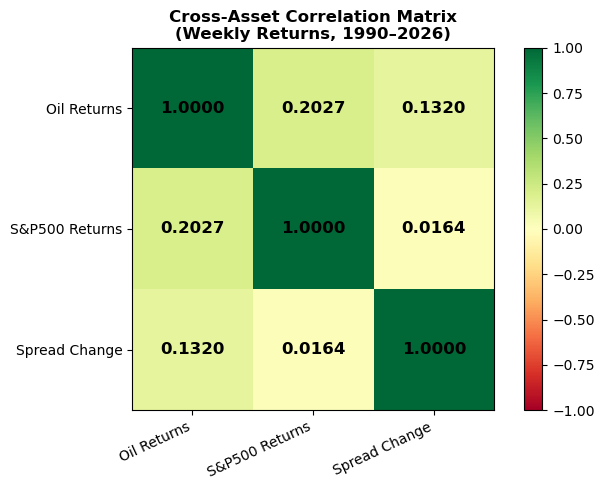

In [66]:
# Cross-Asset Correlation Matrix between oil returns, S&P500 returns and yield curve spread changes
corr_matrix = df_weekly[["r_oil", "r_spx", "d_spread"]].corr()

print("Correlation Matrix:")
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = ["Oil Returns", "S&P500 Returns", "Spread Change"]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.4f}",
                ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="black")

ax.set_title("Cross-Asset Correlation Matrix\n(Weekly Returns, 1990–2026)",
             fontsize=12, fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.show()

The heatmap reports pairwise correlations between oil returns, S&P500 returns and yield curve spread changes. Values range from −1 (perfect negative correlation) to +1 (perfect positive correlation).

## 9. Baseline OLS Regression

We estimate a static baseline regression of weekly S&P500 log returns on lagged oil returns and the lagged yield curve spread change. The model is estimated from scratch using the closed-form OLS estimator.

$$r_{spx,t} = \alpha + \beta_1 \, r_{oil,t-1} + \beta_2 \, \Delta spread_{t-1} + \varepsilon_t \qquad \hat{\beta} = (X'X)^{-1}X'y$$

In [67]:
# Build the regression dataset with lagged regressors
df_reg = df_weekly[["r_spx", "r_oil", "d_spread"]].copy()
df_reg["r_oil_lag1"]    = df_reg["r_oil"].shift(1)
df_reg["d_spread_lag1"] = df_reg["d_spread"].shift(1)
df_reg = df_reg[["r_spx", "r_oil_lag1", "d_spread_lag1"]].dropna()

y = df_reg["r_spx"].to_numpy().reshape(-1, 1)
X = np.column_stack([
    np.ones(len(df_reg)),
    df_reg["r_oil_lag1"].to_numpy(),
    df_reg["d_spread_lag1"].to_numpy()
])
n, k = X.shape

# OLS estimator: beta = (X'X)^{-1} X'y
XtX     = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta_hat = XtX_inv @ (X.T @ y)

y_hat        = X @ beta_hat
ols_residuals = y - y_hat

# Residual variance and standard errors
sigma2_hat  = (ols_residuals.T @ ols_residuals).item() / (n - k)
se_beta_hat = np.sqrt(np.diag(sigma2_hat * XtX_inv)).reshape(-1, 1)
t_stats     = beta_hat / se_beta_hat
p_values    = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))

ols_results = pd.DataFrame({
    "Coefficient" : beta_hat.flatten(),
    "Std Error"   : se_beta_hat.flatten(),
    "t-Statistic" : t_stats.flatten(),
    "p-Value"     : p_values.flatten()
}, index=["Intercept", "Lagged Oil Return", "Lagged Spread Change"]).round(4)

# Goodness of fit
y_mean = np.mean(y)
SST    = np.sum((y - y_mean)**2)
SSR    = (ols_residuals.T @ ols_residuals).item()

R_squared     = 1 - SSR / SST
Adj_R_squared = 1 - (1 - R_squared) * (n - 1) / (n - k)
F_stat        = ((SST - SSR) / (k - 1)) / (SSR / (n - k))
F_p_value     = 1 - stats.f.cdf(F_stat, dfn=k - 1, dfd=n - k)

print("OLS Regression — Baseline Model")
print("-" * 50)
print(f"Observations:       {n}")
print(f"R-squared:          {R_squared:.4f}")
print(f"Adjusted R-squared: {Adj_R_squared:.4f}")
print(f"F-statistic:        {F_stat:.4f}")
print(f"F-test p-value:     {F_p_value:.6f}")
print("-" * 50)
display(ols_results)

OLS Regression — Baseline Model
--------------------------------------------------
Observations:       1887
R-squared:          0.0056
Adjusted R-squared: 0.0045
F-statistic:        5.2772
F-test p-value:     0.005182
--------------------------------------------------


,Coefficient,Std Error,t-Statistic,p-Value
Intercept,0.0016,0.0005,2.9954,0.0028
Lagged Oil Return,-0.0088,0.0107,-0.8243,0.4099
Lagged Spread Change,-0.0202,0.0067,-3.0062,0.0027


## 10. OLS Residual Diagnostics

We examine whether the OLS residuals satisfy the white noise assumption by plotting the ACF of raw and squared residuals and running the Ljung-Box test at lags 4, 8 and 12. Significant autocorrelation in the squared residuals indicates volatility clustering.

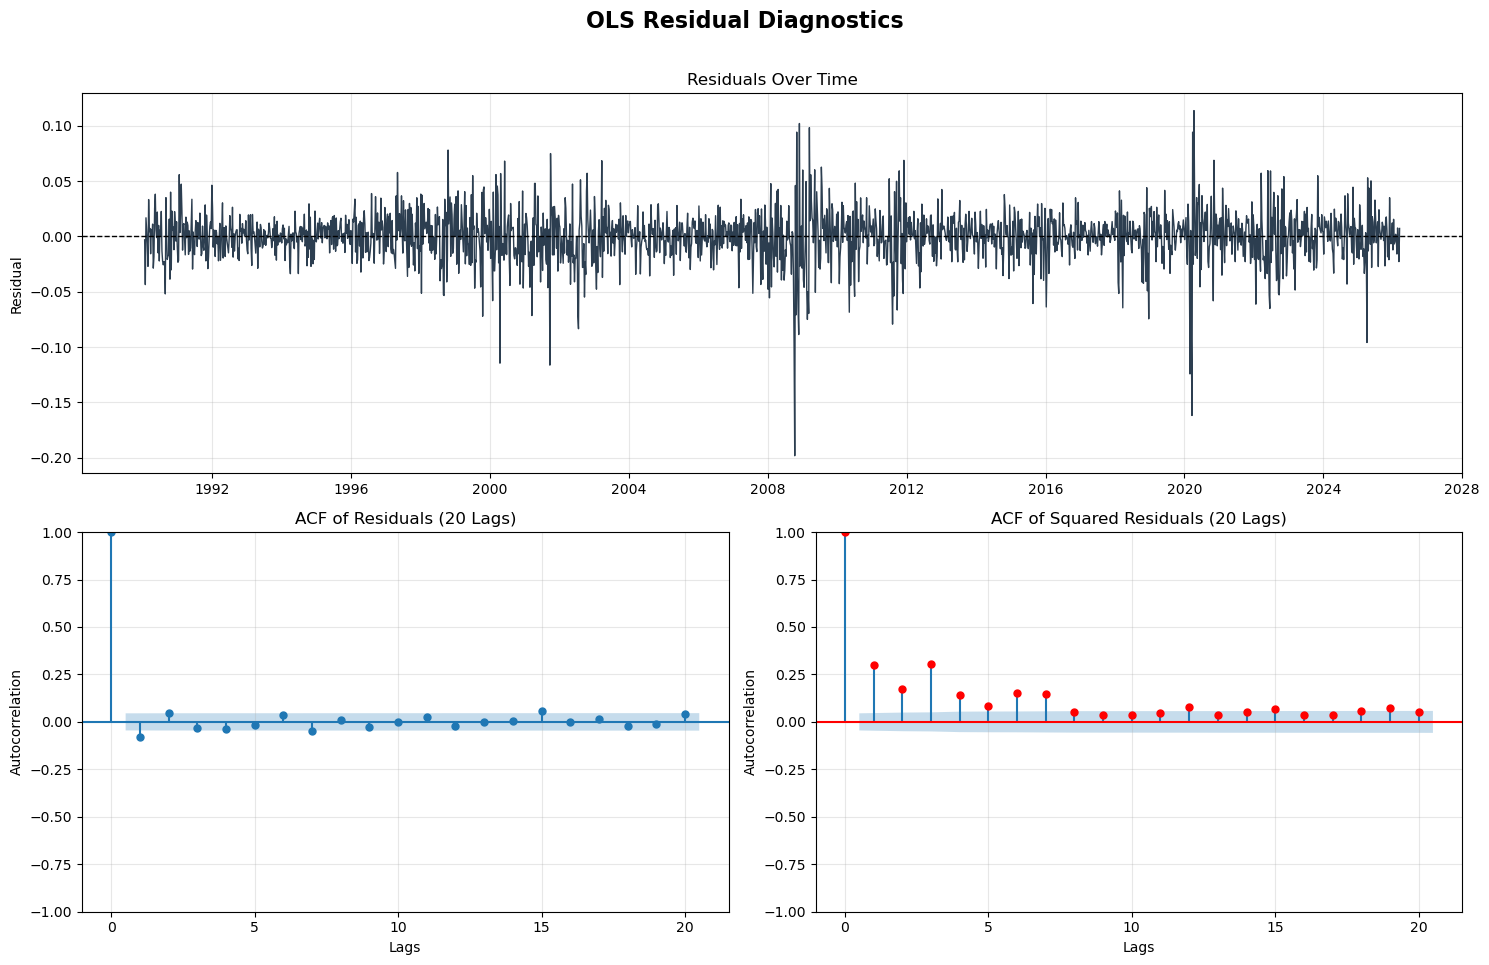

Ljung-Box Autocorrelation Tests:


,LB Statistic,p-value,Reject H0 (5%)?
Test,,,
Residuals (Lag 4),21.9217,0.0002,YES
Residuals (Lag 8),29.0065,0.0003,YES
Residuals (Lag 12),32.9182,0.0010,YES
Squared Residuals (Lag 4),443.1911,0.0000,YES
Squared Residuals (Lag 8),547.6904,0.0000,YES
Squared Residuals (Lag 12),568.1532,0.0000,YES


In [68]:
resids = ols_residuals.flatten()

fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle("OLS Residual Diagnostics", fontsize=16, fontweight='bold', y=0.96)

ax1.plot(df_reg.index, resids, color="#2c3e50", linewidth=1)
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_title("Residuals Over Time")
ax1.set_ylabel("Residual")
ax1.grid(True, alpha=0.3)

plot_acf(resids, lags=20, ax=ax2, alpha=0.05, title="ACF of Residuals (20 Lags)")
ax2.grid(True, alpha=0.3)
ax2.set_ylabel("Autocorrelation")
ax2.set_xlabel("Lags")

plot_acf(resids**2, lags=20, ax=ax3, alpha=0.05, color="red",
         title="ACF of Squared Residuals (20 Lags)")
ax3.grid(True, alpha=0.3)
ax3.set_ylabel("Autocorrelation")
ax3.set_xlabel("Lags")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Ljung-Box test on raw and squared residuals at lags 4, 8, 12
lb_test    = acorr_ljungbox(resids,    lags=[4, 8, 12])
lb_test_sq = acorr_ljungbox(resids**2, lags=[4, 8, 12])

lb_results = []

for lag in [4, 8, 12]:
    lb_results.append({
        "Test"           : f"Residuals (Lag {lag})",
        "LB Statistic"   : lb_test.loc[lag, 'lb_stat'],
        "p-value"        : lb_test.loc[lag, 'lb_pvalue'],
        "Reject H0 (5%)?" : "YES" if lb_test.loc[lag, 'lb_pvalue'] < 0.05 else "NO"
    })

for lag in [4, 8, 12]:
    lb_results.append({
        "Test"           : f"Squared Residuals (Lag {lag})",
        "LB Statistic"   : lb_test_sq.loc[lag, 'lb_stat'],
        "p-value"        : lb_test_sq.loc[lag, 'lb_pvalue'],
        "Reject H0 (5%)?" : "YES" if lb_test_sq.loc[lag, 'lb_pvalue'] < 0.05 else "NO"
    })

df_lb_resids = pd.DataFrame(lb_results).set_index("Test")

print("Ljung-Box Autocorrelation Tests:")
display(df_lb_resids.round(4))

The top panel shows residuals over time. The bottom panels show the ACF of raw and squared residuals. The Ljung-Box table reports whether serial dependence remains in the residuals after OLS estimation.

## 11. Lag Order Selection

We select the optimal AR and MA orders by estimating all ARMAX$(p,q)$ specifications with $p, q \in \{0,1,2,3\}$ on a common aligned sample. Only models that converge and satisfy AR stationarity and MA invertibility are considered admissible. The selected model minimises BIC.

$$AIC = -2\ell + 2k \qquad BIC = -2\ell + k\ln(T) \qquad HQIC = -2\ell + 2k\ln(\ln(T)) \qquad FPE = \hat{\sigma}^2\frac{T+k}{T-k}$$

In [ ]:
warnings.filterwarnings("ignore")

MAX_AR_ORDER = 3
MAX_MA_ORDER = 3
SELECTION_CRITERION = "HQIC"


def prepare_common_sample(df_weekly, max_ar_order):
    # Build a common aligned sample so all candidate models use the same observations
    df_sel = df_weekly[["r_spx", "r_oil", "d_spread"]].copy()
    df_sel["r_oil_lag1"]    = df_sel["r_oil"].shift(1)
    df_sel["d_spread_lag1"] = df_sel["d_spread"].shift(1)
    for lag in range(1, max_ar_order + 1):
        df_sel[f"r_spx_lag{lag}"] = df_sel["r_spx"].shift(lag)
    return df_sel.dropna().copy()


def roots_outside_unit_circle(roots):
    if roots is None or len(roots) == 0:
        return True
    return np.all(np.abs(roots) > 1.0 + 1e-6)


def fit_armax_candidate(y, exog, p, q):
    # Estimate ARMAX(p,q) with exogenous regressors using SARIMAX
    try:
        model = SARIMAX(
            endog=y,
            exog=exog,
            order=(p, 0, q),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False)

        converged     = bool(result.mle_retvals.get("converged", True))
        ar_stable     = roots_outside_unit_circle(getattr(result, "arroots", None))
        ma_invertible = roots_outside_unit_circle(getattr(result, "maroots", None))

        T    = result.nobs
        k    = len(result.params)
        llf  = result.llf
        sse  = np.sum(result.resid ** 2)
        hqic = -2 * llf + 2 * k * np.log(np.log(T))
        fpe  = (sse / T) * ((T + k) / (T - k)) if T > k else np.nan

        return {
            "Model": f"ARMAX({p},{q})", "p": p, "q": q,
            "Converged": converged, "AR Stable": ar_stable,
            "MA Invertible": ma_invertible, "LogLik": llf,
            "AIC": result.aic, "BIC": result.bic,
            "HQIC": hqic, "FPE": fpe,
            "Result": result, "Error": None
        }

    except Exception as e:
        return {
            "Model": f"ARMAX({p},{q})", "p": p, "q": q,
            "Converged": False, "AR Stable": False,
            "MA Invertible": False, "LogLik": np.nan,
            "AIC": np.nan, "BIC": np.nan,
            "HQIC": np.nan, "FPE": np.nan,
            "Result": None, "Error": str(e)
        }


# Build the common sample and estimate all candidates
armax_select_df = prepare_common_sample(df_weekly, MAX_AR_ORDER)
y_select = armax_select_df["r_spx"]
X_select = armax_select_df[["r_oil_lag1", "d_spread_lag1"]]

candidate_results = []
for p in range(MAX_AR_ORDER + 1):
    for q in range(MAX_MA_ORDER + 1):
        candidate_results.append(fit_armax_candidate(y_select, X_select, p, q))

armax_order_table = pd.DataFrame(candidate_results).drop(columns=["Result"])

# Keep only models that converged and satisfy stationarity and invertibility
admissible_models = armax_order_table[
    armax_order_table["Converged"]
    & armax_order_table["AR Stable"]
    & armax_order_table["MA Invertible"]
].copy()

if admissible_models.empty:
    raise ValueError("No admissible ARMAX model found on the grid.")

# Top 3 models for each criterion
top3_aic  = admissible_models.sort_values("AIC").head(3).copy()
top3_aic["Ranking"]  = ["AIC #1",  "AIC #2",  "AIC #3"]
top3_bic  = admissible_models.sort_values("BIC").head(3).copy()
top3_bic["Ranking"]  = ["BIC #1",  "BIC #2",  "BIC #3"]
top3_hqic = admissible_models.sort_values("HQIC").head(3).copy()
top3_hqic["Ranking"] = ["HQIC #1", "HQIC #2", "HQIC #3"]
top3_fpe  = admissible_models.sort_values("FPE").head(3).copy()
top3_fpe["Ranking"]  = ["FPE #1",  "FPE #2",  "FPE #3"]

summary_table = pd.concat(
    [top3_aic, top3_bic, top3_hqic, top3_fpe], axis=0
)[["Ranking", "Model", "p", "q", "AIC", "BIC", "HQIC", "FPE", "LogLik"]].reset_index(drop=True)

# Selected model based on chosen criterion
winner_row          = admissible_models.sort_values(SELECTION_CRITERION).iloc[0]
selected_armax_p    = int(winner_row["p"])
selected_armax_q    = int(winner_row["q"])
selected_armax_model = winner_row["Model"]

print(f"Sample  : {armax_select_df.index.min().date()} to {armax_select_df.index.max().date()}")
print(f"Orders  : p <= {MAX_AR_ORDER}, q <= {MAX_MA_ORDER}")
print(f"Selected: {selected_armax_model} by {SELECTION_CRITERION}")
print()
display(summary_table.round(6))

Sample  : 1990-02-02 to 2026-03-13
Orders  : p <= 3, q <= 3
Selected: ARMAX(1,0) by BIC



,Ranking,Model,p,q,AIC,BIC,HQIC,FPE,LogLik
0,AIC #1,"ARMAX(1,0)",1,0,-8846.999391,-8819.293629,-8836.794937,0.000535,4428.499696
1,AIC #2,"ARMAX(2,0)",2,0,-8842.826293,-8809.582564,-8830.580949,0.000534,4427.413147
2,AIC #3,"ARMAX(1,1)",1,1,-8842.155905,-8808.912176,-8829.910561,0.000534,4427.077953
3,BIC #1,"ARMAX(1,0)",1,0,-8846.999391,-8819.293629,-8836.794937,0.000535,4428.499696
4,BIC #2,"ARMAX(0,0)",0,0,-8836.316063,-8814.151453,-8828.152500,0.000538,4422.158032
5,BIC #3,"ARMAX(0,1)",0,1,-8840.338211,-8812.635103,-8830.133757,0.000535,4425.169105
6,HQIC #1,"ARMAX(1,0)",1,0,-8846.999391,-8819.293629,-8836.794937,0.000535,4428.499696
7,HQIC #2,"ARMAX(2,0)",2,0,-8842.826293,-8809.582564,-8830.580949,0.000534,4427.413147
8,HQIC #3,"ARMAX(0,1)",0,1,-8840.338211,-8812.635103,-8830.133757,0.000535,4425.169105
9,FPE #1,"ARMAX(0,3)",0,3,-8832.983030,-8794.206118,-8818.696794,0.000534,4423.491515


## 12. ARX(1) Estimation — OLS

We extend the baseline model by adding the lagged dependent variable $r_{spx,t-1}$ as an AR(1) term. The model is estimated by OLS using the same closed-form approach as Section 9.

$$r_{spx,t} = \alpha + \phi \, r_{spx,t-1} + \beta_1 \, r_{oil,t-1} + \beta_2 \, \Delta spread_{t-1} + \varepsilon_t \qquad \hat{\beta} = (X'X)^{-1}X'y$$

In [70]:
# Build regression dataset with lagged SPX return as the AR(1) term
df_reg = df_weekly[["r_spx", "r_oil", "d_spread"]].copy()
df_reg["r_spx_lag1"]    = df_reg["r_spx"].shift(1)
df_reg["r_oil_lag1"]    = df_reg["r_oil"].shift(1)
df_reg["d_spread_lag1"] = df_reg["d_spread"].shift(1)
df_reg = df_reg[["r_spx", "r_spx_lag1", "r_oil_lag1", "d_spread_lag1"]].dropna()

y = df_reg["r_spx"].to_numpy().reshape(-1, 1)
X = np.column_stack([
    np.ones(len(df_reg)),
    df_reg["r_spx_lag1"].to_numpy(),
    df_reg["r_oil_lag1"].to_numpy(),
    df_reg["d_spread_lag1"].to_numpy()
])
n, k = X.shape

# OLS estimator: beta = (X'X)^{-1} X'y
XtX      = X.T @ X
XtX_inv  = np.linalg.inv(XtX)
beta_hat = XtX_inv @ (X.T @ y)

y_hat         = X @ beta_hat
ols_residuals = y - y_hat

# Residual variance and standard errors
sigma2_hat  = (ols_residuals.T @ ols_residuals).item() / (n - k)
se_beta_hat = np.sqrt(np.diag(sigma2_hat * XtX_inv)).reshape(-1, 1)
t_stats     = beta_hat / se_beta_hat
p_values    = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))

ols_results = pd.DataFrame({
    "Coefficient" : beta_hat.flatten(),
    "Std Error"   : se_beta_hat.flatten(),
    "t-Statistic" : t_stats.flatten(),
    "p-Value"     : p_values.flatten()
}, index=["Intercept", "Lagged SPX Return", "Lagged Oil Return",
          "Lagged Spread Change"]).round(4)

# Goodness of fit
y_mean        = np.mean(y)
SST           = np.sum((y - y_mean)**2)
SSR           = (ols_residuals.T @ ols_residuals).item()
R_squared     = 1 - SSR / SST
Adj_R_squared = 1 - (1 - R_squared) * (n - 1) / (n - k)
F_stat        = ((SST - SSR) / (k - 1)) / (SSR / (n - k))
F_p_value     = 1 - stats.f.cdf(F_stat, dfn=k - 1, dfd=n - k)

print("ARX(1) — OLS Estimation")
print("-" * 55)
print(f"Observations:       {n}")
print(f"R-squared:          {R_squared:.6f}")
print(f"Adjusted R-squared: {Adj_R_squared:.6f}")
print(f"F-statistic:        {F_stat:.4f}")
print(f"F-test p-value:     {F_p_value:.6f}")
print(f"Residual variance:  {sigma2_hat:.6f}")
print("-" * 55)
display(ols_results)

ARX(1) — OLS Estimation
-------------------------------------------------------
Observations:       1887
R-squared:          0.012242
Adjusted R-squared: 0.010668
F-statistic:        7.7788
F-test p-value:     0.000037
Residual variance:  0.000533
-------------------------------------------------------


,Coefficient,Std Error,t-Statistic,p-Value
Intercept,0.0017,0.0005,3.2326,0.0012
Lagged SPX Return,-0.0834,0.0234,-3.5660,0.0004
Lagged Oil Return,-0.0010,0.0109,-0.0878,0.9301
Lagged Spread Change,-0.0204,0.0067,-3.0535,0.0023


## 13. Static OLS vs ARX(1) — Coefficient Comparison

We compare the coefficients from the static baseline (Section 9) and the dynamic ARX(1) model (Section 12) side by side. The key difference is the inclusion of $r_{spx,t-1}$, which controls for return persistence and may alter the estimated effects of oil and the spread.

In [71]:
# Re-estimate static OLS without the AR term for comparison
X_stat       = np.column_stack([
    np.ones(len(df_reg)),
    df_reg["r_oil_lag1"].to_numpy(),
    df_reg["d_spread_lag1"].to_numpy()
])
inv_XtX_stat = np.linalg.inv(X_stat.T @ X_stat)
beta_stat    = inv_XtX_stat @ X_stat.T @ y
res_stat     = y - X_stat @ beta_stat
se_stat      = np.sqrt(np.diag(
    (res_stat.T @ res_stat).item() / (len(y) - 3) * inv_XtX_stat
))

# ARX(1) with lagged SPX return added
X_arx       = np.column_stack([
    np.ones(len(df_reg)),
    df_reg["r_spx_lag1"].to_numpy(),
    df_reg["r_oil_lag1"].to_numpy(),
    df_reg["d_spread_lag1"].to_numpy()
])
inv_XtX_arx = np.linalg.inv(X_arx.T @ X_arx)
beta_arx    = inv_XtX_arx @ X_arx.T @ y
res_arx     = y - X_arx @ beta_arx
se_arx      = np.sqrt(np.diag(
    (res_arx.T @ res_arx).item() / (len(y) - 4) * inv_XtX_arx
))

idx_stat = ["Intercept", "Lagged Oil Return", "Lagged Spread Change"]
idx_arx  = ["Intercept", "Lagged SPX Return", "Lagged Oil Return", "Lagged Spread Change"]

coef_stat = pd.Series(beta_stat.flatten(), index=idx_stat)
se_stat_s = pd.Series(se_stat.flatten(),   index=idx_stat)
coef_arx  = pd.Series(beta_arx.flatten(),  index=idx_arx)
se_arx_s  = pd.Series(se_arx.flatten(),    index=idx_arx)

comparison = pd.DataFrame({
    "Static OLS Coef" : coef_stat,
    "ARX(1) Coef"     : coef_arx,
    "Difference"      : coef_arx - coef_stat,
    "Static OLS SE"   : se_stat_s,
    "ARX(1) SE"       : se_arx_s
}).fillna("---")

print("Static OLS vs ARX(1) — Coefficient Comparison")
display(comparison)

Static OLS vs ARX(1) — Coefficient Comparison


,Static OLS Coef,ARX(1) Coef,Difference,Static OLS SE,ARX(1) SE
Intercept,0.001598,0.001722,0.000125,0.000533,0.000533
Lagged Oil Return,-0.008841,-0.000958,0.007882,0.010725,0.010918
Lagged SPX Return,---,-0.083357,---,---,0.023375
Lagged Spread Change,-0.020158,-0.020413,-0.000255,0.006706,0.006685


The table reports coefficients and standard errors for both models. The difference column shows the change in each estimate when moving from the static to the dynamic specification. Missing values (---) indicate parameters absent from the static model.

## 14. ARX(1) Residual Diagnostics

We apply the same diagnostic procedure as in Section 10 to the ARX(1) residuals. The ACF of raw residuals tests for remaining linear autocorrelation, while the ACF of squared residuals tests for volatility clustering.

$$\hat{\varepsilon}_t = r_{spx,t} - \hat{\alpha} - \hat{\phi}\,r_{spx,t-1} - \hat{\beta}_1\,r_{oil,t-1} - \hat{\beta}_2\,\Delta spread_{t-1}$$

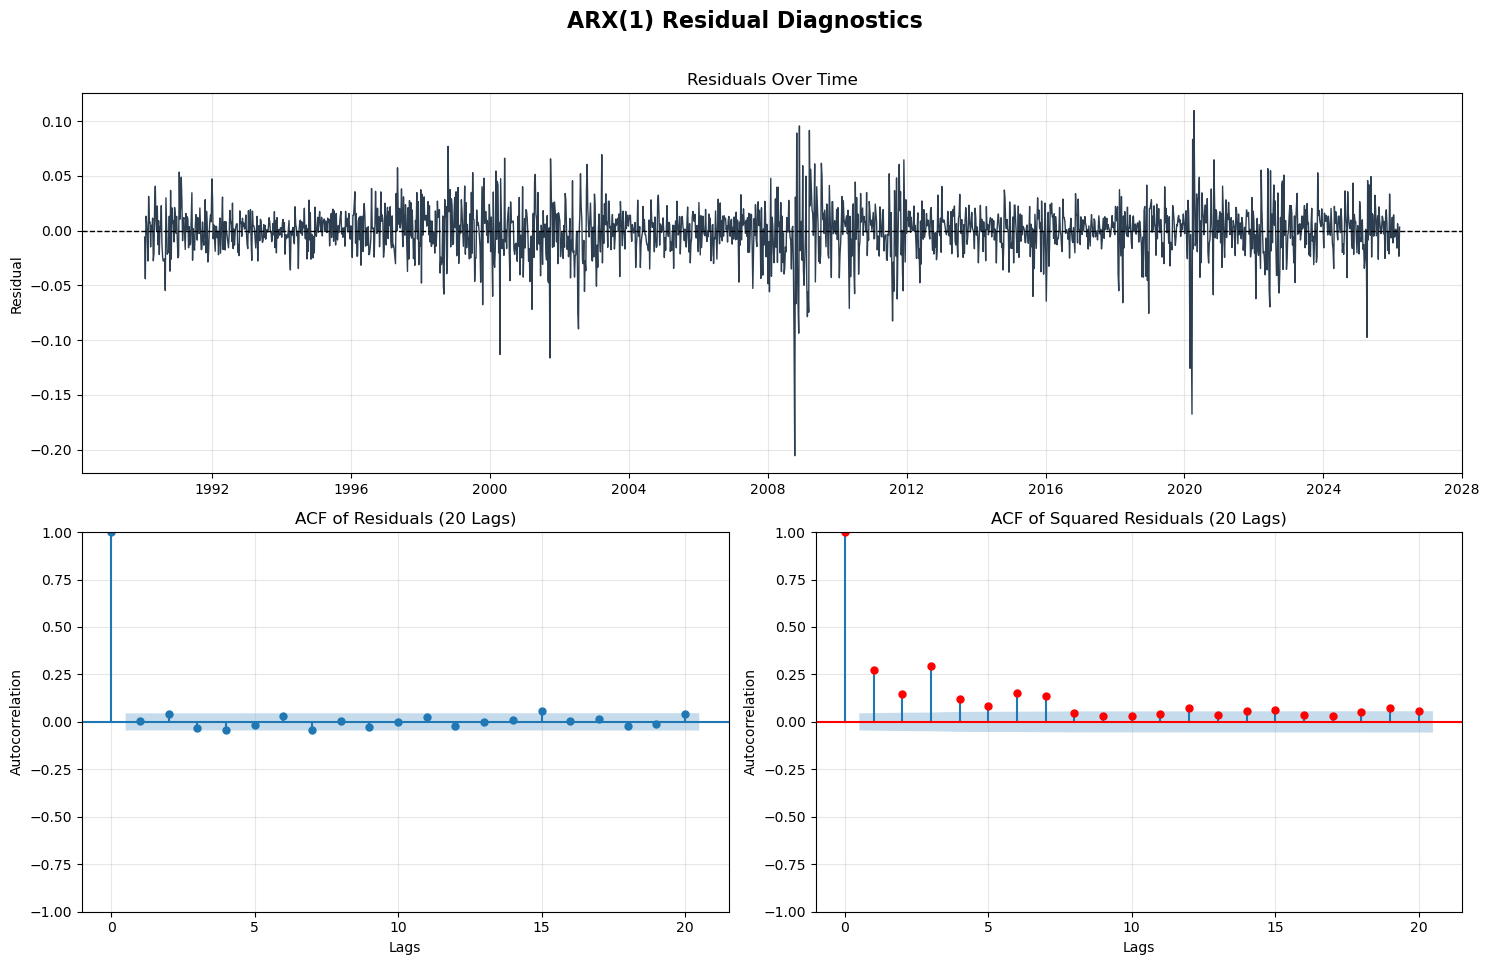

Ljung-Box Autocorrelation Tests — ARX(1) Residuals:


,LB Statistic,p-value,Reject H0 (5%)?
Test,,,
Residuals (Lag 4),8.2456,0.0830,NO
Residuals (Lag 8),13.9523,0.0830,NO
Residuals (Lag 12),17.7118,0.1247,NO
Squared Residuals (Lag 4),374.0325,0.0000,YES
Squared Residuals (Lag 8),472.6691,0.0000,YES
Squared Residuals (Lag 12),489.2986,0.0000,YES


In [72]:
resids_arx = ols_residuals.flatten()

fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle("ARX(1) Residual Diagnostics", fontsize=16, fontweight='bold', y=0.96)

ax1.plot(df_reg.index, resids_arx, color="#2c3e50", linewidth=1)
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_title("Residuals Over Time")
ax1.set_ylabel("Residual")
ax1.grid(True, alpha=0.3)

plot_acf(resids_arx, lags=20, ax=ax2, alpha=0.05,
         title="ACF of Residuals (20 Lags)")
ax2.grid(True, alpha=0.3)
ax2.set_ylabel("Autocorrelation")
ax2.set_xlabel("Lags")

plot_acf(resids_arx**2, lags=20, ax=ax3, alpha=0.05, color="red",
         title="ACF of Squared Residuals (20 Lags)")
ax3.grid(True, alpha=0.3)
ax3.set_ylabel("Autocorrelation")
ax3.set_xlabel("Lags")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Ljung-Box on raw and squared residuals at lags 4, 8, 12
lags_to_test = [4, 8, 12]
lb_test    = acorr_ljungbox(resids_arx,    lags=lags_to_test)
lb_test_sq = acorr_ljungbox(resids_arx**2, lags=lags_to_test)

lb_results_arx = []

for lag in lags_to_test:
    lb_results_arx.append({
        "Test"            : f"Residuals (Lag {lag})",
        "LB Statistic"    : lb_test.loc[lag, 'lb_stat'],
        "p-value"         : lb_test.loc[lag, 'lb_pvalue'],
        "Reject H0 (5%)?" : "YES" if lb_test.loc[lag, 'lb_pvalue'] < 0.05 else "NO"
    })

for lag in lags_to_test:
    lb_results_arx.append({
        "Test"            : f"Squared Residuals (Lag {lag})",
        "LB Statistic"    : lb_test_sq.loc[lag, 'lb_stat'],
        "p-value"         : lb_test_sq.loc[lag, 'lb_pvalue'],
        "Reject H0 (5%)?" : "YES" if lb_test_sq.loc[lag, 'lb_pvalue'] < 0.05 else "NO"
    })

df_lb_arx = pd.DataFrame(lb_results_arx).set_index("Test")

print("Ljung-Box Autocorrelation Tests — ARX(1) Residuals:")
display(df_lb_arx.round(4))

The top panel shows ARX(1) residuals over time. The bottom panels show the ACF of raw and squared residuals. The Ljung-Box table reports test results at lags 4, 8 and 12 for both series.

## 15. Transmission Channel 1 — Oil Shocks and the Yield Curve

We test the first link of the transmission chain by regressing the weekly change in the yield curve spread on the lagged oil log return. A negative coefficient would indicate that oil price increases are followed by a flattening of the yield curve, consistent with Bernanke, Gertler and Watson (1997).

$$\Delta spread_t = \alpha + \beta \, r_{oil,t-1} + \varepsilon_t$$

In [73]:
# Regress yield curve spread change on lagged oil return
df_5a = pd.DataFrame({
    "d_spread"  : df_weekly["d_spread"],
    "r_oil_lag1": df_weekly["r_oil"].shift(1)
}).dropna()

y_5a = df_5a["d_spread"].to_numpy().reshape(-1, 1)
X_5a = np.column_stack([
    np.ones(len(df_5a)),
    df_5a["r_oil_lag1"].to_numpy()
])
n_5a, k_5a = X_5a.shape

# OLS estimator
XtX_5a     = X_5a.T @ X_5a
XtX_inv_5a = np.linalg.inv(XtX_5a)
beta_5a    = XtX_inv_5a @ (X_5a.T @ y_5a)

resid_5a    = y_5a - X_5a @ beta_5a
sigma2_5a   = (resid_5a.T @ resid_5a).item() / (n_5a - k_5a)
se_5a       = np.sqrt(np.diag(sigma2_5a * XtX_inv_5a)).reshape(-1, 1)
t_5a        = beta_5a / se_5a
p_5a        = 2 * (1 - stats.t.cdf(np.abs(t_5a), df=n_5a - k_5a))

y_mean_5a = np.mean(y_5a)
SST_5a    = np.sum((y_5a - y_mean_5a) ** 2)
SSR_5a    = (resid_5a.T @ resid_5a).item()
R2_5a     = 1 - SSR_5a / SST_5a
AdjR2_5a  = 1 - (1 - R2_5a) * (n_5a - 1) / (n_5a - k_5a)

results_5a = pd.DataFrame({
    "Coefficient" : beta_5a.flatten(),
    "Std Error"   : se_5a.flatten(),
    "t-Statistic" : t_5a.flatten(),
    "p-Value"     : p_5a.flatten()
}, index=["Intercept", "r_oil (lag 1)"])

print("Oil Returns → Yield Curve Spread")
print(f"Observations  : {n_5a}")
print(f"R-squared     : {R2_5a:.6f}")
print(f"Adj R-squared : {AdjR2_5a:.6f}")
print()
display(results_5a.round(6))

Oil Returns → Yield Curve Spread
Observations  : 1887
R-squared     : 0.000666
Adj R-squared : 0.000136



,Coefficient,Std Error,t-Statistic,p-Value
Intercept,0.000247,0.001847,0.133578,0.893750
r_oil (lag 1),-0.041283,0.036822,-1.121171,0.262358


## 16. Transmission Channel 2 — Yield Curve and Forward Equity Returns

We test the second link of the transmission chain by regressing the cumulative S&P500 return over the following four weeks on the current week's yield curve spread change. A positive coefficient confirms that yield curve flattening predicts negative equity returns over the following month.

$$\sum_{h=1}^{4} r_{spx,t+h} = \alpha + \beta \, \Delta spread_t + \varepsilon_t$$

In [74]:
# Cumulative 4-week forward S&P500 return regressed on current yield curve spread change
df_5b = pd.DataFrame({
    "d_spread"   : df_weekly["d_spread"],
    "r_spx_fwd1" : df_weekly["r_spx"].shift(-1),
    "r_spx_fwd2" : df_weekly["r_spx"].shift(-2),
    "r_spx_fwd3" : df_weekly["r_spx"].shift(-3),
    "r_spx_fwd4" : df_weekly["r_spx"].shift(-4),
}).dropna()

df_5b["fwd_cum_return"] = (
    df_5b["r_spx_fwd1"] +
    df_5b["r_spx_fwd2"] +
    df_5b["r_spx_fwd3"] +
    df_5b["r_spx_fwd4"]
)

print(f"Observations : {len(df_5b)}")
print(f"Date range   : {df_5b.index.min().date()} to {df_5b.index.max().date()}")
print(f"Mean forward return : {df_5b['fwd_cum_return'].mean():.6f}")
print(f"Std  forward return : {df_5b['fwd_cum_return'].std():.6f}")

y_5b = df_5b["fwd_cum_return"].to_numpy().reshape(-1, 1)
X_5b = np.column_stack([
    np.ones(len(df_5b)),
    df_5b["d_spread"].to_numpy()
])
n_5b, k_5b = X_5b.shape

# OLS estimator
XtX_5b     = X_5b.T @ X_5b
XtX_inv_5b = np.linalg.inv(XtX_5b)
beta_5b    = XtX_inv_5b @ (X_5b.T @ y_5b)

resid_5b  = y_5b - X_5b @ beta_5b
sigma2_5b = (resid_5b.T @ resid_5b).item() / (n_5b - k_5b)
se_5b     = np.sqrt(np.diag(sigma2_5b * XtX_inv_5b)).reshape(-1, 1)
t_5b      = beta_5b / se_5b
p_5b      = 2 * (1 - stats.t.cdf(np.abs(t_5b), df=n_5b - k_5b))

y_mean_5b = np.mean(y_5b)
SST_5b    = np.sum((y_5b - y_mean_5b) ** 2)
SSR_5b    = (resid_5b.T @ resid_5b).item()
R2_5b     = 1 - SSR_5b / SST_5b
AdjR2_5b  = 1 - (1 - R2_5b) * (n_5b - 1) / (n_5b - k_5b)

results_5b = pd.DataFrame({
    "Coefficient" : beta_5b.flatten(),
    "Std Error"   : se_5b.flatten(),
    "t-Statistic" : t_5b.flatten(),
    "p-Value"     : p_5b.flatten()
}, index=["Intercept", "dSpread (current)"])

print("\nYield Curve Spread → Forward Equity Returns")
print(f"Observations  : {n_5b}")
print(f"R-squared     : {R2_5b:.6f}")
print(f"Adj R-squared : {AdjR2_5b:.6f}")
print()
display(results_5b.round(6))

Observations : 1884
Date range   : 1990-01-12 to 2026-02-13
Mean forward return : 0.006407
Std  forward return : 0.044280

Yield Curve Spread → Forward Equity Returns
Observations  : 1884
R-squared     : 0.000271
Adj R-squared : -0.000260



,Coefficient,Std Error,t-Statistic,p-Value
Intercept,0.00641,0.001020,6.282384,0.000000
dSpread (current),-0.00908,0.012708,-0.714464,0.475029


## 17. Transmission Chain Visualization

Three complementary charts illustrate the relationship between the yield curve spread change and the cumulative four-week ahead S&P500 return. The rolling correlation uses a 52-week window and is computed as:

$$\rho_t = \text{Corr}(\Delta spread_t,\, \sum_{h=1}^{4} r_{spx,t+h})$$

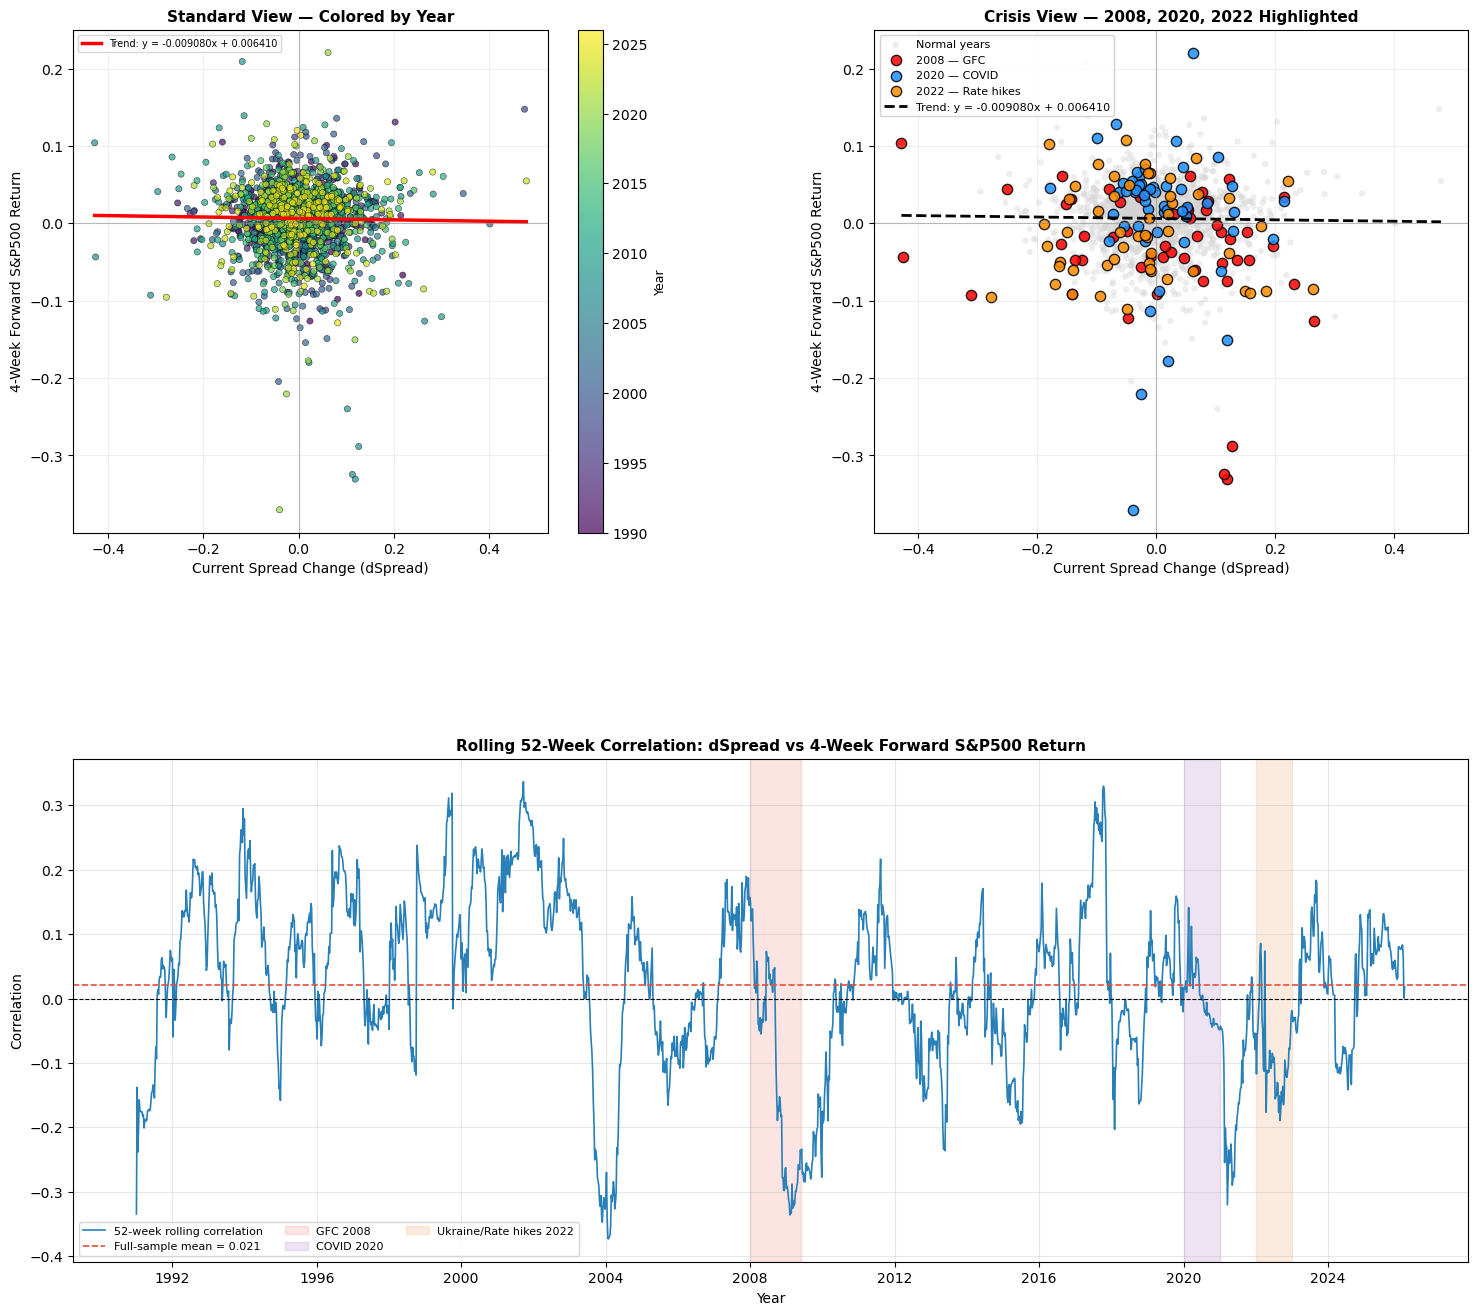

Regression: fwd_return = -0.009080 x dSpread + 0.006410

Rolling correlation — full sample mean : 0.0211
During GFC 2008                        : -0.1525
During COVID 2020                      : 0.0057
During 2022                            : -0.0931


In [75]:
years  = df_5b.index.year
x_vals = df_5b["d_spread"].to_numpy()
y_vals = df_5b["fwd_cum_return"].to_numpy()

slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line  = np.linspace(x_vals.min(), x_vals.max(), 100)
y_line  = slope * x_line + intercept
eq_label = f"Trend: y = {slope:.6f}x + {intercept:.6f}"

m_08    = years == 2008
m_20    = years == 2020
m_22    = years == 2022
m_other = ~(m_08 | m_20 | m_22)

# 52-week rolling correlation between spread change and forward equity return
WINDOW    = 52
roll_corr = df_5b["d_spread"].rolling(WINDOW).corr(df_5b["fwd_cum_return"])

fig = plt.figure(figsize=(18, 16))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

scatter1 = ax1.scatter(
    x_vals, y_vals,
    c=years, cmap="viridis", alpha=0.7,
    edgecolors="black", linewidths=0.4, s=20
)
ax1.plot(x_line, y_line, color="red", linewidth=2.5, label=eq_label)
cbar = plt.colorbar(scatter1, ax=ax1)
cbar.set_label("Year", fontsize=9)
ax1.set_title("Standard View — Colored by Year", fontsize=11, fontweight="bold")
ax1.set_xlabel("Current Spread Change (dSpread)", fontsize=10)
ax1.set_ylabel("4-Week Forward S&P500 Return", fontsize=10)
ax1.axhline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)
ax1.axvline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)
ax1.legend(loc="upper left", fontsize=7)
ax1.grid(True, alpha=0.2)

ax2.scatter(x_vals[m_other], y_vals[m_other],
            color="lightgray", alpha=0.4, edgecolors="none",
            s=20, label="Normal years")
ax2.scatter(x_vals[m_08], y_vals[m_08],
            color="red", alpha=0.85, edgecolors="black",
            s=55, label="2008 — GFC")
ax2.scatter(x_vals[m_20], y_vals[m_20],
            color="dodgerblue", alpha=0.85, edgecolors="black",
            s=55, label="2020 — COVID")
ax2.scatter(x_vals[m_22], y_vals[m_22],
            color="darkorange", alpha=0.85, edgecolors="black",
            s=55, label="2022 — Rate hikes")
ax2.plot(x_line, y_line, color="black", linewidth=2,
         linestyle="--", label=eq_label)
ax2.set_title("Crisis View — 2008, 2020, 2022 Highlighted",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Current Spread Change (dSpread)", fontsize=10)
ax2.set_ylabel("4-Week Forward S&P500 Return", fontsize=10)
ax2.axhline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)
ax2.axvline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)
ax2.legend(loc="upper left", fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.2)

ax3.plot(df_5b.index, roll_corr,
         color="#2980b9", linewidth=1.2, label="52-week rolling correlation")
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.axhline(roll_corr.mean(), color="#e74c3c", linewidth=1.2,
            linestyle="--", label=f"Full-sample mean = {roll_corr.mean():.3f}")

for start, end, color, label in [
    ("2008-01-01", "2009-06-01", "#e74c3c", "GFC 2008"),
    ("2020-01-01", "2020-12-31", "#8e44ad", "COVID 2020"),
    ("2022-01-01", "2022-12-31", "#e67e22", "Ukraine/Rate hikes 2022"),
]:
    ax3.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                alpha=0.15, color=color, label=label)

ax3.set_title("Rolling 52-Week Correlation: dSpread vs 4-Week Forward S&P500 Return",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Correlation", fontsize=10)
ax3.legend(fontsize=8, loc="lower left", ncol=3)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Regression: fwd_return = {slope:.6f} x dSpread + {intercept:.6f}")
print(f"\nRolling correlation — full sample mean : {roll_corr.mean():.4f}")
print(f"During GFC 2008                        : {roll_corr['2008':'2009'].mean():.4f}")
print(f"During COVID 2020                      : {roll_corr['2020':'2020'].mean():.4f}")
print(f"During 2022                            : {roll_corr['2022':'2022'].mean():.4f}")

The top-left panel shows the full scatter colored by year with a regression line. The top-right panel highlights the 2008, 2020 and 2022 crisis episodes. The bottom panel shows how the rolling correlation between the two variables evolves over the full sample period.

## 18. VAR System — Lag Order Selection

To complement the single-equation analysis, we estimate a Vector Autoregression (VAR) on the three variables simultaneously. The variable ordering follows Bernanke, Gertler and Watson (1997): oil first as the exogenous shock, spread second as the transmission channel, equities third as the outcome. The lag order is selected by minimising BIC over $p \in \{1, \dots, 12\}$.

$$y_t = c + A_1 y_{t-1} + \cdots + A_p y_{t-p} + u_t \qquad y_t = \begin{pmatrix} r_{oil,t} \\ \Delta spread_t \\ r_{spx,t} \end{pmatrix}$$

In [ ]:
MAX_VAR_LAG = 12
VAR_SELECTION_CRITERION = "HQIC"

# Build the VAR dataset — ordering: oil first, spread second, equities third
df_var = df_weekly[["r_oil", "d_spread", "r_spx"]].dropna().copy()

# Estimate candidate VAR(p) models for each lag order
var_results = []
for lag in range(1, MAX_VAR_LAG + 1):
    try:
        fitted = VAR(df_var).fit(lag)
        var_results.append({
            "Lag"          : lag,
            "AIC"          : fitted.aic,
            "BIC"          : fitted.bic,
            "HQIC"         : fitted.hqic,
            "FPE"          : fitted.fpe,
            "Observations" : int(fitted.nobs),
            "Result"       : fitted,
            "Error"        : None
        })
    except Exception as e:
        var_results.append({
            "Lag"          : lag,
            "AIC"          : np.nan,
            "BIC"          : np.nan,
            "HQIC"         : np.nan,
            "FPE"          : np.nan,
            "Observations" : np.nan,
            "Result"       : None,
            "Error"        : str(e)
        })

var_lag_table         = pd.DataFrame(var_results)
var_lag_table_display = var_lag_table[["Lag", "AIC", "BIC", "HQIC", "FPE", "Observations"]].copy()

valid_var_models = var_lag_table.dropna(subset=["AIC", "BIC", "HQIC", "FPE"]).copy()
if valid_var_models.empty:
    raise ValueError("No valid VAR model estimated on the lag grid.")

best_var_aic  = int(valid_var_models.sort_values("AIC").iloc[0]["Lag"])
best_var_bic  = int(valid_var_models.sort_values("BIC").iloc[0]["Lag"])
best_var_hqic = int(valid_var_models.sort_values("HQIC").iloc[0]["Lag"])
best_var_fpe  = int(valid_var_models.sort_values("FPE").iloc[0]["Lag"])

selected_var_lag = {
    "AIC" : best_var_aic,
    "BIC" : best_var_bic,
    "HQIC": best_var_hqic,
    "FPE" : best_var_fpe
}[VAR_SELECTION_CRITERION]

# Estimate the final VAR on the selected lag
var_result = VAR(df_var).fit(selected_var_lag)

print("=" * 78)
print("VAR Lag Selection and Estimation")
print("=" * 78)
print(f"Sample               : {df_var.index.min().date()} to {df_var.index.max().date()}")
print(f"Variables            : r_oil, d_spread, r_spx")
print(f"Maximum lag tested   : {MAX_VAR_LAG}")
print(f"Best lag by AIC      : {best_var_aic}")
print(f"Best lag by BIC      : {best_var_bic}")
print(f"Best lag by HQIC     : {best_var_hqic}")
print(f"Best lag by FPE      : {best_var_fpe}")
print(f"Selected lag ({VAR_SELECTION_CRITERION}) : {selected_var_lag}")
print("-" * 78)
display(var_lag_table_display.round(6))

VAR Lag Selection and Estimation
Sample               : 1990-01-12 to 2026-03-13
Variables            : r_oil, d_spread, r_spx
Maximum lag tested   : 12
Best lag by AIC      : 8
Best lag by BIC      : 1
Best lag by HQIC     : 1
Best lag by FPE      : 8
Selected lag (BIC) : 1
------------------------------------------------------------------------------


,Lag,AIC,BIC,HQIC,FPE,Observations
0,1,-18.629865,-18.594617,-18.616885,0.0,1887
1,2,-18.626968,-18.565257,-18.604242,0.0,1886
2,3,-18.625351,-18.537154,-18.592870,0.0,1885
3,4,-18.634543,-18.519838,-18.592298,0.0,1884
4,5,-18.631559,-18.490322,-18.579542,0.0,1883
5,6,-18.631655,-18.463863,-18.569856,0.0,1882
6,7,-18.631519,-18.437149,-18.559929,0.0,1881
7,8,-18.638435,-18.417464,-18.557045,0.0,1880
8,9,-18.633652,-18.386056,-18.542453,0.0,1879
9,10,-18.627169,-18.352924,-18.526151,0.0,1878


## 19. VAR(1) Estimation

We estimate the VAR(1) model and report the coefficient table for each equation separately. Each equation is estimated by OLS. Significance stars follow the standard convention.

In [77]:
# Fit VAR(1) on the selected variable ordering
var_data     = df_weekly[["r_spx", "r_oil", "d_spread"]].dropna()
model_var    = VAR(var_data)
results_var1 = model_var.fit(1)

print(f"Observations : {results_var1.nobs}")
print(f"Lag order    : {results_var1.k_ar}")
print(f"AIC          : {results_var1.aic:.4f}")
print(f"BIC          : {results_var1.bic:.4f}")
print("-" * 78)

def get_stars(pval):
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

params  = results_var1.params
stderrs = results_var1.stderr
tvals   = results_var1.tvalues
pvals   = results_var1.pvalues

eq_names = {
    "r_spx"   : "Equation 1: S&P 500 Returns (r_spx)",
    "r_oil"   : "Equation 2: Oil Returns (r_oil)",
    "d_spread": "Equation 3: Yield Spread Changes (d_spread)"
}

for col in params.columns:
    df_eq = pd.DataFrame({
        "Coefficient": params[col],
        "Std. Error" : stderrs[col],
        "t-stat"     : tvals[col],
        "P>|t|"      : pvals[col]
    })

    df_eq["Sig."]        = df_eq["P>|t|"].apply(get_stars)
    df_eq["Coefficient"] = df_eq["Coefficient"].map("{:+.6f}".format)
    df_eq["Std. Error"]  = df_eq["Std. Error"].map("{:.6f}".format)
    df_eq["t-stat"]      = df_eq["t-stat"].map("{:+.4f}".format)
    df_eq["P>|t|"]       = df_eq["P>|t|"].map("{:.4f}".format)
    df_eq.index          = [idx.replace("L1.", "Lag 1 ") for idx in df_eq.index]

    print(f"\n{eq_names.get(col, col)}")
    print("-" * 55)
    display(df_eq)

print("\nSignificance codes:  0.01 '***'  0.05 '**'  0.10 '*'")

Observations : 1887
Lag order    : 1
AIC          : -18.6299
BIC          : -18.5946
------------------------------------------------------------------------------

Equation 1: S&P 500 Returns (r_spx)
-------------------------------------------------------


,Coefficient,Std. Error,t-stat,P>|t|,Sig.
const,+0.001722,0.000533,+3.2326,0.0012,***
Lag 1 r_spx,-0.083357,0.023375,-3.5660,0.0004,***
Lag 1 r_oil,-0.000958,0.010918,-0.0878,0.9301,
Lag 1 d_spread,-0.020413,0.006685,-3.0535,0.0023,***



Equation 2: Oil Returns (r_oil)
-------------------------------------------------------


,Coefficient,Std. Error,t-stat,P>|t|,Sig.
const,+0.000646,0.001156,+0.5591,0.5761,
Lag 1 r_spx,+0.048784,0.050699,+0.9622,0.3359,
Lag 1 r_oil,+0.002417,0.023680,+0.1021,0.9187,
Lag 1 d_spread,-0.041338,0.014500,-2.8510,0.0044,***



Equation 3: Yield Spread Changes (d_spread)
-------------------------------------------------------


,Coefficient,Std. Error,t-stat,P>|t|,Sig.
const,+0.000652,0.001845,+0.3537,0.7236,
Lag 1 r_spx,-0.267228,0.080918,-3.3024,0.0010,***
Lag 1 r_oil,-0.005253,0.037794,-0.1390,0.8895,
Lag 1 d_spread,-0.051800,0.023142,-2.2384,0.0252,**



Significance codes:  0.01 '***'  0.05 '**'  0.10 '*'


## 20. VAR(1) Stability and Residual Diagnostics

A VAR is stable if all roots of the characteristic polynomial lie strictly outside the unit circle, which guarantees that impulse responses converge to zero. We also run the Ljung-Box test on the residuals of each equation at lag 12 to check for remaining serial dependence.

In [78]:
# Stability check — all roots of the characteristic polynomial must lie outside the unit circle
roots = results_var1.roots

stability_table = pd.DataFrame({
    "Real Part"               : np.real(roots),
    "Imaginary Part"          : np.imag(roots),
    "Modulus"                 : np.abs(roots),
}).round(4)

is_stable = np.all(np.abs(roots) > 1)

print("VAR Stability Check")
print("-" * 65)
display(stability_table)
print(f"All roots outside unit circle: {'YES' if is_stable else 'NO'}")

# Ljung-Box test on VAR residuals at lag 12
LAG_CHECK  = 12
lb_output  = {}

for variable in results_var1.resid.columns:
    lb_output[variable] = acorr_ljungbox(
        results_var1.resid[variable], lags=[LAG_CHECK], return_df=True
    )

lb_table = pd.concat(lb_output, axis=0)
lb_table.index.names = ["Equation", "Lags"]
lb_table.columns     = ["LB Statistic", "P-Value"]

print(f"\nLjung-Box Test — Residuals at Lag {LAG_CHECK}")
print("-" * 65)
display(lb_table.round(4))

for eq in results_var1.resid.columns:
    pval   = lb_table.loc[(eq, LAG_CHECK), "P-Value"]
    status = "white noise" if pval > 0.05 else "autocorrelation remains"
    print(f"  {eq:<10} p = {pval:.4f}  →  {status}")

VAR Stability Check
-----------------------------------------------------------------


,Real Part,Imaginary Part,Modulus
0,-277.2590,0.0,277.2590
1,68.4485,0.0,68.4485
2,-6.9569,0.0,6.9569


All roots outside unit circle: YES

Ljung-Box Test — Residuals at Lag 12
-----------------------------------------------------------------


,,LB Statistic,P-Value
Equation,Lags,,
r_spx,12,17.7118,0.1247
r_oil,12,21.4655,0.0440
d_spread,12,58.4930,0.0000


  r_spx      p = 0.1247  →  white noise
  r_oil      p = 0.0440  →  autocorrelation remains
  d_spread   p = 0.0000  →  autocorrelation remains


The stability table reports the real part, imaginary part and modulus of each root. The Ljung-Box table reports the test statistic and p-value for each equation's residuals at lag 12.

## 21. Impulse Response Functions

We compute orthogonalized IRFs using Cholesky decomposition of the residual covariance matrix, consistent with the variable ordering. Each chart traces the response of S&P500 returns to a one standard deviation shock over a 24-week horizon. The shaded bands are 95% confidence intervals.

$$u_t = P\varepsilon_t \qquad \Sigma_u = PP'$$

where $P$ is the lower triangular Cholesky factor and $\varepsilon_t$ contains orthogonal structural shocks.

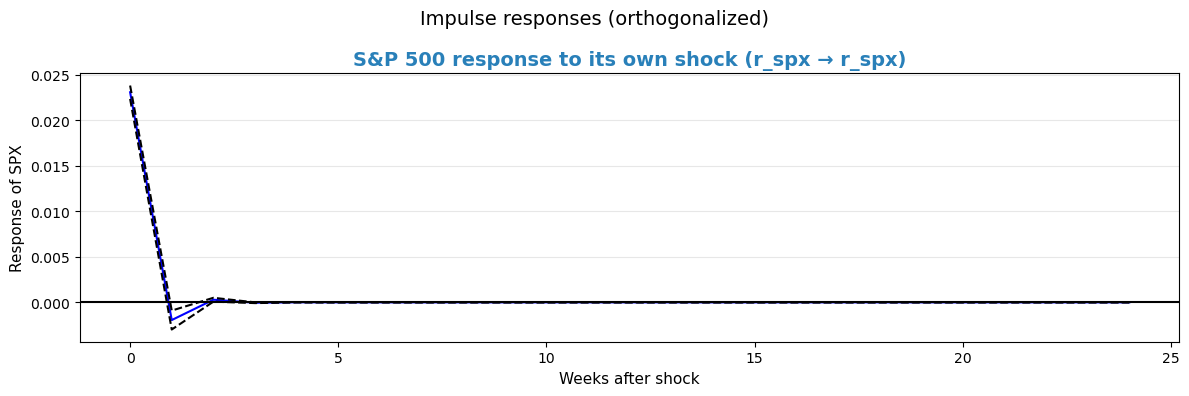

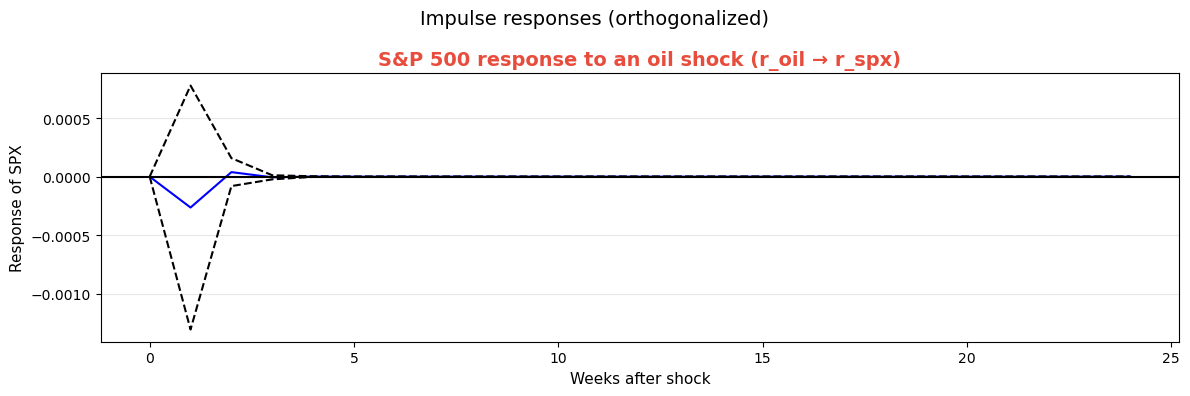

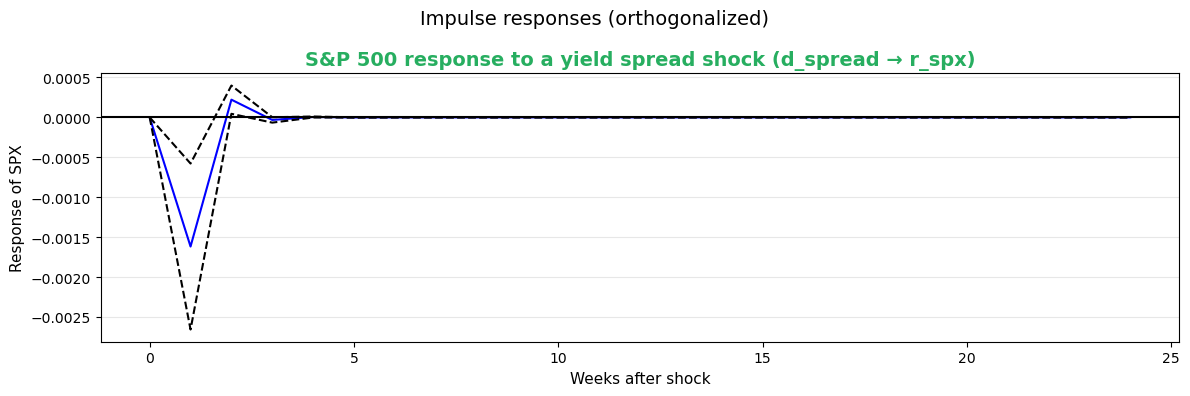

In [79]:
# Orthogonalized IRF — response of S&P500 to shocks from each variable
irf_periods = 24
irf = results_var1.irf(irf_periods)

# Response of S&P500 to its own shock
fig1 = irf.plot(impulse='r_spx', response='r_spx', orth=True, signif=0.05, figsize=(12, 4))
ax1  = fig1.gca()
ax1.set_title("S&P 500 response to its own shock (r_spx → r_spx)",
              fontsize=14, fontweight="bold", color="#2980b9")
ax1.axhline(0, color='black', linewidth=1.2, linestyle='-')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlabel("Weeks after shock", fontsize=11)
ax1.set_ylabel("Response of SPX", fontsize=11)
plt.tight_layout()
plt.show()

# Response of S&P500 to an oil shock
fig2 = irf.plot(impulse='r_oil', response='r_spx', orth=True, signif=0.05, figsize=(12, 4))
ax2  = fig2.gca()
ax2.set_title("S&P 500 response to an oil shock (r_oil → r_spx)",
              fontsize=14, fontweight="bold", color="#e74c3c")
ax2.axhline(0, color='black', linewidth=1.2, linestyle='-')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xlabel("Weeks after shock", fontsize=11)
ax2.set_ylabel("Response of SPX", fontsize=11)
plt.tight_layout()
plt.show()

# Response of S&P500 to a yield spread shock
fig3 = irf.plot(impulse='d_spread', response='r_spx', orth=True, signif=0.05, figsize=(12, 4))
ax3  = fig3.gca()
ax3.set_title("S&P 500 response to a yield spread shock (d_spread → r_spx)",
              fontsize=14, fontweight="bold", color="#27ae60")
ax3.axhline(0, color='black', linewidth=1.2, linestyle='-')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xlabel("Weeks after shock", fontsize=11)
ax3.set_ylabel("Response of SPX", fontsize=11)
plt.tight_layout()
plt.show()

The three charts show the response of S&P500 returns to its own shock, to an oil shock and to a yield spread shock. Bars outside the confidence band indicate a statistically significant response at that horizon.

## 22. Rolling Forecast Setup

We evaluate out-of-sample forecasting ability by re-estimating all models every week on a rolling window of 156 observations (three years) and producing one-step-ahead forecasts. Four models are compared: ARX(1), VAR(1), AR(1) and the Random Walk. At each step $t$, only data up to $t-1$ is used, ensuring no look-ahead bias.

In [80]:
WINDOW = 156  # 3 years of weekly observations

# Use the ARX(1) dataset as the base for the rolling sample
df_roll = df_reg.copy()

# Add raw unlagged series for the VAR — it handles its own lags internally
if 'r_oil' not in df_roll.columns:
    df_roll['r_oil'] = df_weekly['r_oil']
if 'd_spread' not in df_roll.columns:
    df_roll['d_spread'] = df_weekly['d_spread']

df_roll = df_roll.dropna()
n_total = len(df_roll)

oos_start_idx = WINDOW
n_forecasts   = n_total - oos_start_idx

if n_forecasts <= 0:
    raise ValueError("Not enough observations for a 156-week rolling window.")

forecasts_arx = []
forecasts_var = []
forecasts_ar1 = []
forecasts_rw  = []
actuals       = []
dates         = []

print("=" * 60)
print("ROLLING FORECAST SETUP (4-MODEL COMPETITION)")
print("=" * 60)
print(f"Main model (1)               : ARX(1)")
print(f"Main model (2)               : VAR(1)")
print(f"Total observations available : {n_total}")
print(f"Rolling window size          : {WINDOW} weeks (3 years)")
print(f"Out-of-sample start index    : {oos_start_idx}")
print(f"Out-of-sample start date     : {df_roll.index[oos_start_idx].date()}")
print(f"Out-of-sample end date       : {df_roll.index[-1].date()}")
print(f"Number of rolling iterations : {n_forecasts}")
print(f"Benchmark 1                  : AR(1)")
print(f"Benchmark 2                  : Random Walk (forecast = 0)")
print("=" * 60)

ROLLING FORECAST SETUP (4-MODEL COMPETITION)
Main model (1)               : ARX(1)
Main model (2)               : VAR(1)
Total observations available : 1887
Rolling window size          : 156 weeks (3 years)
Out-of-sample start index    : 156
Out-of-sample start date     : 1993-01-15
Out-of-sample end date       : 2026-03-13
Number of rolling iterations : 1731
Benchmark 1                  : AR(1)
Benchmark 2                  : Random Walk (forecast = 0)


## 23. Rolling Forecast Loop

At each iteration $t$, the ARX(1) and AR(1) models are re-estimated by OLS on the current window, and the VAR(1) is re-fitted using statsmodels. The Random Walk always predicts zero. All forecasts use only information available at time $t-1$.

$$\hat{r}_{spx,t} = \hat{\alpha} + \hat{\phi}\,r_{spx,t-1} + \hat{\beta}_1\,r_{oil,t-1} + \hat{\beta}_2\,\Delta spread_{t-1}$$

In [81]:
arr_y          = df_roll["r_spx"].to_numpy()
arr_y_lag      = df_roll["r_spx_lag1"].to_numpy()
arr_oil        = df_roll["r_oil_lag1"].to_numpy()
arr_spread     = df_roll["d_spread_lag1"].to_numpy()

# VAR uses unlagged series and handles lags internally
arr_oil_raw    = df_roll["r_oil"].to_numpy()
arr_spread_raw = df_roll["d_spread"].to_numpy()

def fit_arx_window(y_w, y_lag_w, oil_w, spread_w):
    X_arx = np.column_stack([np.ones(len(y_w)), y_lag_w, oil_w, spread_w])
    XtX   = X_arx.T @ X_arx
    XtY   = X_arx.T @ y_w
    try:
        beta           = np.linalg.solve(XtX, XtY)
        solved_directly = True
    except np.linalg.LinAlgError:
        beta           = np.linalg.pinv(XtX) @ XtY
        solved_directly = False
    return beta, solved_directly

def fit_ar1_window(y_w, y_lag_w):
    X_ar   = np.column_stack([np.ones(len(y_w)), y_lag_w])
    XtX_ar = X_ar.T @ X_ar
    XtY_ar = X_ar.T @ y_w
    try:
        beta_ar = np.linalg.solve(XtX_ar, XtY_ar)
    except np.linalg.LinAlgError:
        beta_ar = np.linalg.pinv(XtX_ar) @ XtY_ar
    return beta_ar

forecasts_arx    = np.zeros(n_forecasts)
forecasts_var    = np.zeros(n_forecasts)
forecasts_ar1    = np.zeros(n_forecasts)
forecasts_rw     = np.zeros(n_forecasts)
actuals          = np.zeros(n_forecasts)
rolling_beta_oil = np.zeros(n_forecasts)
fit_flags        = np.zeros(n_forecasts, dtype=bool)
dates            = []

print("Starting rolling 4-model loop...")
print(f"Total iterations: {n_forecasts}")
print("-" * 75)

for i in range(n_forecasts):
    t = oos_start_idx + i

    y_w          = arr_y[t - WINDOW : t]
    y_lag_w      = arr_y_lag[t - WINDOW : t]
    oil_w        = arr_oil[t - WINDOW : t]
    spread_w     = arr_spread[t - WINDOW : t]
    oil_raw_w    = arr_oil_raw[t - WINDOW : t]
    spread_raw_w = arr_spread_raw[t - WINDOW : t]

    beta_arx, solved_directly = fit_arx_window(y_w, y_lag_w, oil_w, spread_w)
    beta_ar1                  = fit_ar1_window(y_w, y_lag_w)

    # VAR(1) estimated on the rolling window
    var_data_w = np.column_stack([y_w, oil_raw_w, spread_raw_w])
    res_var    = VAR(var_data_w).fit(1)

    alpha_f, phi_f, b_oil_f, b_spread_f = beta_arx
    fc_arx = (alpha_f + phi_f * arr_y_lag[t] + b_oil_f * arr_oil[t] +
              b_spread_f * arr_spread[t])
    fc_ar1 = beta_ar1[0] + beta_ar1[1] * arr_y_lag[t]

    # VAR one-step-ahead forecast — r_spx is at index 0
    last_obs   = var_data_w[-1:]
    fc_var_sys = res_var.forecast(y=last_obs, steps=1)
    fc_var     = fc_var_sys[0, 0]

    forecasts_arx[i]    = fc_arx
    forecasts_var[i]    = fc_var
    forecasts_ar1[i]    = fc_ar1
    forecasts_rw[i]     = 0.0
    actuals[i]          = arr_y[t]
    rolling_beta_oil[i] = b_oil_f
    fit_flags[i]        = solved_directly
    dates.append(df_roll.index[t])

    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1:4d} / {n_forecasts} | Date: {df_roll.index[t].date()} | "
              f"Solve OK: {solved_directly} | ARX fc: {fc_arx:+.5f} | VAR fc: {fc_var:+.5f}")

print("-" * 75)
print(f"Loop complete. {len(actuals)} forecasts generated.")
print(f"ARX numerical fallback: {np.sum(~fit_flags)}")

Starting rolling 4-model loop...
Total iterations: 1731
---------------------------------------------------------------------------
Iteration  100 / 1731 | Date: 1994-12-09 | Solve OK: True | ARX fc: +0.00232 | VAR fc: +0.00211
Iteration  200 / 1731 | Date: 1996-11-08 | Solve OK: True | ARX fc: +0.00635 | VAR fc: +0.00640
Iteration  300 / 1731 | Date: 1998-10-09 | Solve OK: True | ARX fc: +0.01086 | VAR fc: +0.01086
Iteration  400 / 1731 | Date: 2000-09-08 | Solve OK: True | ARX fc: +0.00684 | VAR fc: +0.00688
Iteration  500 / 1731 | Date: 2002-08-09 | Solve OK: True | ARX fc: -0.01114 | VAR fc: -0.01139
Iteration  600 / 1731 | Date: 2004-07-09 | Solve OK: True | ARX fc: -0.00298 | VAR fc: -0.00333
Iteration  700 / 1731 | Date: 2006-06-09 | Solve OK: True | ARX fc: +0.00121 | VAR fc: +0.00119
Iteration  800 / 1731 | Date: 2008-05-09 | Solve OK: True | ARX fc: -0.00032 | VAR fc: -0.00028
Iteration  900 / 1731 | Date: 2010-04-09 | Solve OK: True | ARX fc: +0.00033 | VAR fc: +0.00031
Iter

## 24. Out-of-Sample RMSE Comparison

We evaluate forecast accuracy using the Root Mean Squared Error computed over all out-of-sample periods. The relative improvement is expressed as a percentage reduction in RMSE versus the Random Walk baseline.

$$RMSE = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(\hat{r}_{spx,t} - r_{spx,t})^2} \qquad \Delta RMSE\% = \frac{RMSE_{RW} - RMSE_{model}}{RMSE_{RW}} \times 100$$

In [82]:
fc_arx_arr  = np.array(forecasts_arx)
fc_var_arr  = np.array(forecasts_var)
fc_ar1_arr  = np.array(forecasts_ar1)
fc_rw_arr   = np.array(forecasts_rw)
actuals_arr = np.array(actuals)
dates_arr   = pd.DatetimeIndex(dates)

def rmse(forecasts, actuals):
    errors = forecasts - actuals
    return np.sqrt(np.mean(errors ** 2))

rmse_arx = rmse(fc_arx_arr, actuals_arr)
rmse_var = rmse(fc_var_arr,  actuals_arr)
rmse_ar1 = rmse(fc_ar1_arr,  actuals_arr)
rmse_rw  = rmse(fc_rw_arr,   actuals_arr)

# Relative improvement over the random walk baseline
rel_arx = (rmse_rw - rmse_arx) / rmse_rw * 100
rel_var = (rmse_rw - rmse_var) / rmse_rw * 100
rel_ar1 = (rmse_rw - rmse_ar1) / rmse_rw * 100
rel_rw  = 0.0

rmse_table = pd.DataFrame({
    "Model"                        : ["ARX(1) — Main model (1)",
                                      "VAR(1) — Main model (2)",
                                      "AR(1)  — Benchmark 1",
                                      "Random Walk — Benchmark 2"],
    "RMSE"                         : [rmse_arx, rmse_var, rmse_ar1, rmse_rw],
    "Improvement vs Random Walk %" : [rel_arx,  rel_var,  rel_ar1,  rel_rw]
})

rmse_table["RMSE"]                         = rmse_table["RMSE"].round(6)
rmse_table["Improvement vs Random Walk %"] = rmse_table["Improvement vs Random Walk %"].round(4)

print("=" * 70)
print("Out-of-Sample RMSE Comparison — 4 Models")
print("=" * 70)
display(rmse_table)

comp_arx_ar1 = (rmse_ar1 - rmse_arx) / rmse_ar1 * 100
comp_var_ar1 = (rmse_ar1 - rmse_var) / rmse_ar1 * 100
comp_arx_var = (rmse_var - rmse_arx) / rmse_var * 100

print(f"\nBest model       : {rmse_table.loc[rmse_table['RMSE'].idxmin(), 'Model']}")
print("-" * 35)
print(f"ARX(1) vs RW     : {rel_arx:+.4f}%")
print(f"VAR(1) vs RW     : {rel_var:+.4f}%")
print(f"AR(1)  vs RW     : {rel_ar1:+.4f}%")
print("-" * 35)
print(f"ARX(1) vs AR(1)  : {comp_arx_ar1:+.4f}%")
print(f"VAR(1) vs AR(1)  : {comp_var_ar1:+.4f}%")
print(f"ARX(1) vs VAR(1) : {comp_arx_var:+.4f}%")

Out-of-Sample RMSE Comparison — 4 Models


,Model,RMSE,Improvement vs Random Walk %
0,ARX(1) — Main model (1),0.024370,-2.9154
1,VAR(1) — Main model (2),0.024383,-2.9718
2,AR(1) — Benchmark 1,0.023918,-1.0063
3,Random Walk — Benchmark 2,0.023680,0.0000



Best model       : Random Walk — Benchmark 2
-----------------------------------
ARX(1) vs RW     : -2.9154%
VAR(1) vs RW     : -2.9718%
AR(1)  vs RW     : -1.0063%
-----------------------------------
ARX(1) vs AR(1)  : -1.8901%
VAR(1) vs AR(1)  : -1.9459%
ARX(1) vs VAR(1) : +0.0548%


## 25. RMSE Summary Cards

Visual summary of the RMSE results for all four models. Each card displays the RMSE value, the rank and the percentage improvement or deterioration relative to the Random Walk baseline.

In [83]:
models    = ["ARX(1) — OLS", "VAR(1) — System", "AR(1) — OLS benchmark", "Random Walk — baseline"]
rmse_vals = [rmse_arx, rmse_var, rmse_ar1, rmse_rw]
subtitles = ["Full model: AR term, oil, spread",
             "Structural: multivariate dynamics",
             "Benchmark: past returns only",
             "Simple benchmark: forecast = 0"]

best_idx  = int(np.argmin(rmse_vals))
worst_idx = int(np.argmax(rmse_vals))

ranks = ["", "", "", ""]
for i, v in enumerate(rmse_vals):
    sorted_vals = sorted(rmse_vals)
    ranks[i] = ["1st", "2nd", "3rd", "4th"][sorted_vals.index(v)]

def impr(model_rmse):
    pct   = (rmse_rw - model_rmse) / rmse_rw * 100
    sign  = "▼" if pct > 0 else "▲"
    color = "#27ae60" if pct > 0 else "#e74c3c"
    return sign, abs(pct), color

cards_html = ""
for i, (model, rmse_val, sub) in enumerate(zip(models, rmse_vals, subtitles)):

    is_best  = (i == best_idx)
    is_worst = (i == worst_idx)

    border     = "2.5px solid #27ae60" if is_best else "0.5px solid #dfe6e9"
    badge_html = ""
    if is_best:
        badge_html = """
        <div style="position:absolute;top:-11px;left:14px;
                    background:#27ae60;color:white;font-size:10px;
                    font-weight:600;padding:2px 10px;border-radius:4px;
                    letter-spacing:0.5px">
          ✓ BEST MODEL
        </div>"""
    elif is_worst:
        badge_html = """
        <div style="position:absolute;top:-11px;left:14px;
                    background:#e74c3c;color:white;font-size:10px;
                    font-weight:600;padding:2px 10px;border-radius:4px;
                    letter-spacing:0.5px">
          WORST MODEL
        </div>"""

    sign, pct, color = impr(rmse_val)
    rank_color = "#27ae60" if ranks[i] == "1st" else \
                 "#2980b9" if ranks[i] == "2nd" else \
                 "#e67e22" if ranks[i] == "3rd" else "#e74c3c"

    bar_pct = (1 - (rmse_val - min(rmse_vals)) /
               max(max(rmse_vals) - min(rmse_vals), 1e-10)) * 100
    bar_pct   = max(bar_pct, 20)
    bar_color = "#27ae60" if is_best else "#e74c3c" if is_worst else "#3498db"

    cards_html += f"""
    <div style="background:white;border-radius:12px;padding:22px 20px 18px;
                border:{border};position:relative;
                box-shadow:0 1px 6px rgba(0,0,0,0.07)">
      {badge_html}
      <div style="font-size:12px;font-weight:600;color:#2c3e50;margin-bottom:2px">
        {model}
      </div>
      <div style="font-size:10px;color:#95a5a6;margin-bottom:12px">{sub}</div>
      <div style="font-size:30px;font-weight:500;color:#2c3e50;line-height:1">
        {rmse_val:.5f}
      </div>
      <div style="font-size:10px;color:#95a5a6;margin-top:2px;
                  margin-bottom:10px">RMSE — lower is better</div>
      <div style="background:#f0f3f4;border-radius:4px;height:5px;margin-bottom:12px">
        <div style="background:{bar_color};height:5px;border-radius:4px;
                    width:{bar_pct:.0f}%"></div>
      </div>
      <div style="padding-top:10px;border-top:0.5px solid #ecf0f1">
        <div style="font-size:12px;font-weight:700;color:{rank_color}">
          Rank {ranks[i]} of 4
        </div>
        <div style="font-size:11px;color:{color};font-weight:600;margin-top:3px">
          {sign} {pct:.4f}% vs random walk
        </div>
      </div>
    </div>"""

html = f"""
<div style="font-family:sans-serif;margin:16px 0">
  <div style="font-size:13px;color:#7f8c8d;margin-bottom:14px;font-weight:500">
    Out-of-sample RMSE — rolling 156-week window — {len(actuals):,} forecasts
  </div>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:16px">
    {cards_html}
  </div>
</div>
"""

display(HTML(html))

print("=" * 65)
print("RMSE Summary")
print("=" * 65)
print(f"ARX(1)     : {rmse_arx:.6f}  ({(rmse_rw - rmse_arx)/rmse_rw*100:+.4f}% vs RW)")
print(f"VAR(1)     : {rmse_var:.6f}  ({(rmse_rw - rmse_var)/rmse_rw*100:+.4f}% vs RW)")
print(f"AR(1)      : {rmse_ar1:.6f}  ({(rmse_rw - rmse_ar1)/rmse_rw*100:+.4f}% vs RW)")
print(f"Random Walk: {rmse_rw:.6f}  (baseline)")
print(f"\nBest model : {models[best_idx]}")

RMSE Summary
ARX(1)     : 0.024370  (-2.9154% vs RW)
VAR(1)     : 0.024383  (-2.9718% vs RW)
AR(1)      : 0.023918  (-1.0063% vs RW)
Random Walk: 0.023680  (baseline)

Best model : Random Walk — baseline


## 26. Rolling RMSE Over Time

The rolling RMSE is computed over a 52-week moving window to examine how forecast accuracy evolves over time. The main chart covers the full out-of-sample period from 1993 to 2026. The three bottom panels zoom in on the GFC 2008, COVID 2020 and Ukraine 2022 episodes.

$$RMSE_t = \sqrt{\frac{1}{52}\sum_{s=t-51}^{t}(\hat{r}_{spx,s} - r_{spx,s})^2}$$

Variables already in memory — proceeding


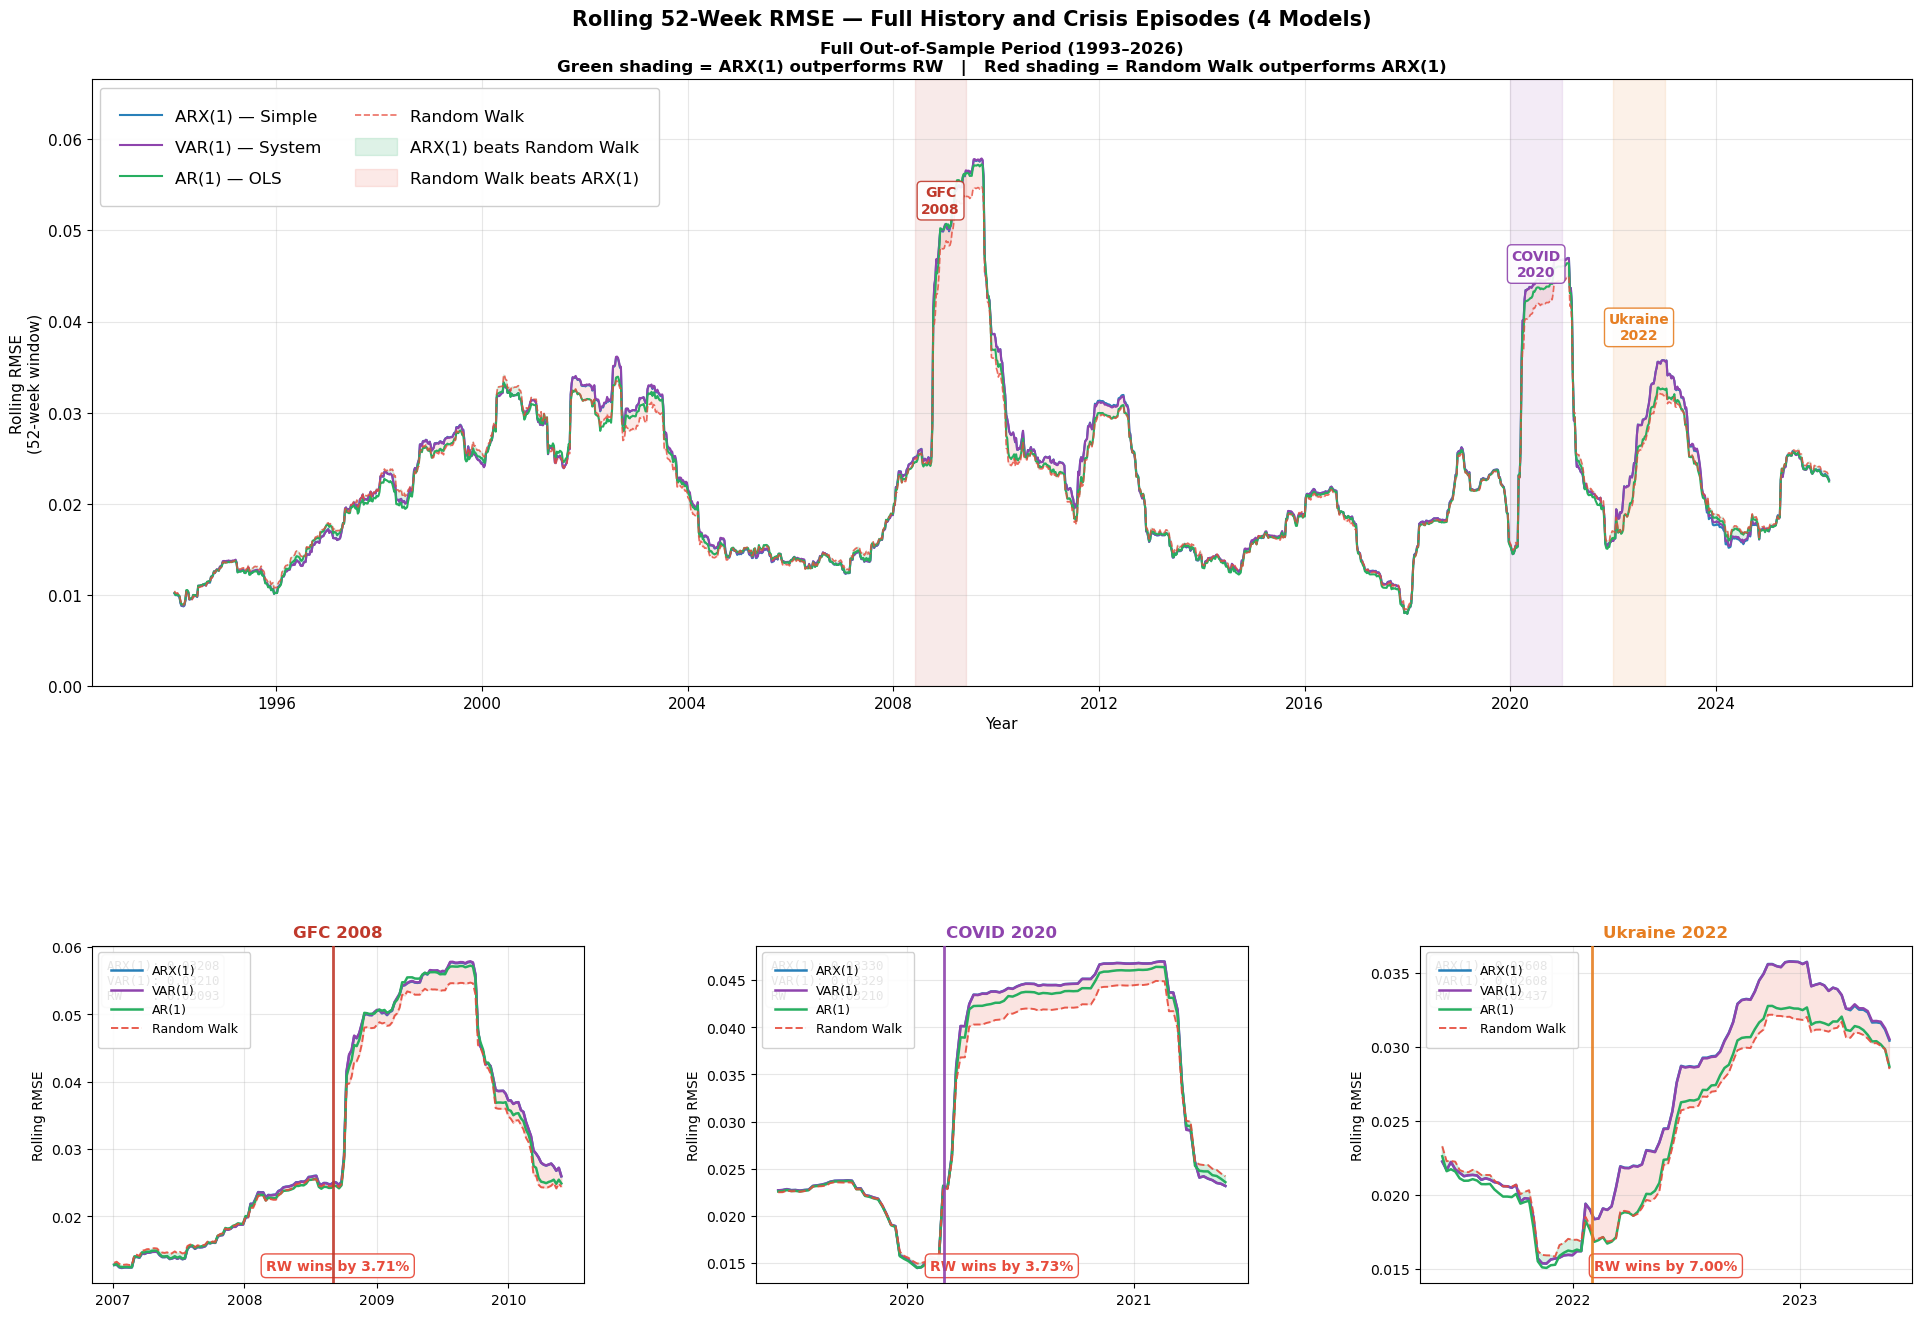

Crisis Period Rolling RMSE Summary

GFC 2008:
  ARX(1) RMSE: 0.03208 (-3.71% vs RW)
  VAR(1) RMSE: 0.03210 (-3.78% vs RW)
  RW RMSE    : 0.03093
  Winner     : Random Walk

COVID 2020:
  ARX(1) RMSE: 0.03330 (-3.73% vs RW)
  VAR(1) RMSE: 0.03329 (-3.70% vs RW)
  RW RMSE    : 0.03210
  Winner     : Random Walk

Ukraine 2022:
  ARX(1) RMSE: 0.02608 (-7.00% vs RW)
  VAR(1) RMSE: 0.02608 (-6.99% vs RW)
  RW RMSE    : 0.02437
  Winner     : Random Walk


In [84]:
try:
    rolling_rmse_var
    print("Variables already in memory — proceeding")
except NameError:
    print("Rebuilding rolling RMSE from forecast arrays...")
    df_errors = pd.DataFrame({
        "error_arx": (fc_arx_arr - actuals_arr) ** 2,
        "error_var": (fc_var_arr - actuals_arr) ** 2,
        "error_ar1": (fc_ar1_arr - actuals_arr) ** 2,
        "error_rw":  (fc_rw_arr  - actuals_arr) ** 2,
    }, index=dates_arr)
    ROLL = 52
    rolling_rmse_arx = np.sqrt(df_errors["error_arx"].rolling(ROLL).mean())
    rolling_rmse_var = np.sqrt(df_errors["error_var"].rolling(ROLL).mean())
    rolling_rmse_ar1 = np.sqrt(df_errors["error_ar1"].rolling(ROLL).mean())
    rolling_rmse_rw  = np.sqrt(df_errors["error_rw"].rolling(ROLL).mean())
    print("Rolling RMSE rebuilt successfully")

fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1.8, 1])

ax_main  = fig.add_subplot(gs[0, :])
ax_gfc   = fig.add_subplot(gs[1, 0])
ax_covid = fig.add_subplot(gs[1, 1])
ax_ukr   = fig.add_subplot(gs[1, 2])

fig.suptitle("Rolling 52-Week RMSE — Full History and Crisis Episodes (4 Models)",
             fontsize=15, fontweight="bold", y=0.98)

ax_main.plot(rolling_rmse_arx.index, rolling_rmse_arx,
             color="#2980b9", linewidth=1.5, label="ARX(1) — Simple", zorder=3)
ax_main.plot(rolling_rmse_var.index, rolling_rmse_var,
             color="#8e44ad", linewidth=1.5, label="VAR(1) — System", zorder=3)
ax_main.plot(rolling_rmse_ar1.index, rolling_rmse_ar1,
             color="#27ae60", linewidth=1.5, label="AR(1) — OLS", zorder=3)
ax_main.plot(rolling_rmse_rw.index, rolling_rmse_rw,
             color="#e74c3c", linewidth=1.2, label="Random Walk",
             zorder=3, linestyle="--", alpha=0.8)

ax_main.fill_between(rolling_rmse_arx.index,
                     rolling_rmse_arx, rolling_rmse_rw,
                     where=(rolling_rmse_arx <= rolling_rmse_rw),
                     alpha=0.15, color="#27ae60", label="ARX(1) beats Random Walk")
ax_main.fill_between(rolling_rmse_arx.index,
                     rolling_rmse_arx, rolling_rmse_rw,
                     where=(rolling_rmse_arx > rolling_rmse_rw),
                     alpha=0.12, color="#e74c3c", label="Random Walk beats ARX(1)")

ymax = max(rolling_rmse_arx.dropna().max(),
           rolling_rmse_var.dropna().max(),
           rolling_rmse_ar1.dropna().max(),
           rolling_rmse_rw.dropna().max())

crises_main = [
    ("2008-06-01", "2009-06-01", "#c0392b", "GFC\n2008",     0.92),
    ("2020-01-01", "2020-12-31", "#8e44ad", "COVID\n2020",   0.80),
    ("2022-01-01", "2022-12-31", "#e67e22", "Ukraine\n2022", 0.68),
]

for start, end, color, label, y_frac in crises_main:
    ax_main.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.10, color=color, zorder=1)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax_main.text(mid, ymax * y_frac, label,
                 color=color, fontsize=10, fontweight="bold",
                 ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.3",
                           facecolor="white", edgecolor=color, alpha=0.9))

ax_main.set_ylim(0, ymax * 1.15)
ax_main.set_title("Full Out-of-Sample Period (1993–2026)\n"
                  "Green shading = ARX(1) outperforms RW   |   "
                  "Red shading = Random Walk outperforms ARX(1)",
                  fontsize=12, fontweight="bold")
ax_main.set_xlabel("Year", fontsize=11)
ax_main.set_ylabel("Rolling RMSE\n(52-week window)", fontsize=11)
ax_main.legend(fontsize=12, loc="upper left", ncol=2,
               framealpha=0.95, edgecolor="#cccccc",
               borderpad=1.2, labelspacing=0.8,
               handlelength=2.5, handleheight=1.2)
ax_main.grid(True, alpha=0.3)
ax_main.xaxis.set_major_locator(mdates.YearLocator(4))
ax_main.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_main.tick_params(axis="x", labelsize=11)
ax_main.tick_params(axis="y", labelsize=11)

crisis_windows = [
    (ax_gfc,   "GFC 2008",     "2007-01-01", "2010-06-01", "#c0392b", "2008-09-01"),
    (ax_covid, "COVID 2020",   "2019-06-01", "2021-06-01", "#8e44ad", "2020-03-01"),
    (ax_ukr,   "Ukraine 2022", "2021-06-01", "2023-06-01", "#e67e22", "2022-02-01"),
]

for ax, title, start, end, color, event_date in crisis_windows:

    mask = (rolling_rmse_arx.index >= start) & (rolling_rmse_arx.index <= end)
    x    = rolling_rmse_arx.index[mask]
    arx  = rolling_rmse_arx[mask]
    var  = rolling_rmse_var[mask]
    ar1  = rolling_rmse_ar1[mask]
    rw   = rolling_rmse_rw[mask]

    ax.plot(x, arx, color="#2980b9", linewidth=1.8, label="ARX(1)", zorder=3)
    ax.plot(x, var, color="#8e44ad", linewidth=1.8, label="VAR(1)", zorder=3)
    ax.plot(x, ar1, color="#27ae60", linewidth=1.8, label="AR(1)",  zorder=3)
    ax.plot(x, rw,  color="#e74c3c", linewidth=1.4, label="Random Walk",
            zorder=3, linestyle="--", alpha=0.9)

    ax.fill_between(x, arx, rw, where=(arx <= rw), alpha=0.18, color="#27ae60")
    ax.fill_between(x, arx, rw, where=(arx > rw),  alpha=0.15, color="#e74c3c")

    ax.axvline(pd.Timestamp(event_date),
               color=color, linewidth=2, linestyle="-", alpha=0.9, zorder=4)

    arx_mean = arx.mean()
    var_mean = var.mean()
    rw_mean  = rw.mean()

    winner       = "ARX(1) wins" if arx_mean < rw_mean else "RW wins"
    winner_color = "#27ae60"     if arx_mean < rw_mean else "#e74c3c"
    diff_pct     = abs(rw_mean - arx_mean) / rw_mean * 100

    ax.set_title(f"{title}", fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("", fontsize=10)
    ax.set_ylabel("Rolling RMSE", fontsize=10)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9,
              handlelength=2.5, borderpad=1.0)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=10, rotation=0)
    ax.tick_params(axis="y", labelsize=10)

    ax.text(0.03, 0.96,
            f"ARX(1): {arx_mean:.5f}\nVAR(1): {var_mean:.5f}\nRW    : {rw_mean:.5f}",
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white", edgecolor="#cccccc", alpha=0.9))

    ax.annotate(f"{winner} by {diff_pct:.2f}%",
                xy=(0.5, 0.04), xycoords="axes fraction",
                ha="center", fontsize=10, fontweight="bold", color=winner_color,
                bbox=dict(boxstyle="round,pad=0.35",
                          facecolor="white", edgecolor=winner_color, alpha=0.95))

plt.subplots_adjust(top=0.93, bottom=0.07, left=0.06,
                    right=0.97, hspace=0.55, wspace=0.35)
plt.show()

print("=" * 65)
print("Crisis Period Rolling RMSE Summary")
print("=" * 65)
for _, title, start, end, color, _ in crisis_windows:
    mask     = (rolling_rmse_arx.index >= start) & (rolling_rmse_arx.index <= end)
    a        = rolling_rmse_arx[mask].mean()
    v        = rolling_rmse_var[mask].mean()
    r        = rolling_rmse_rw[mask].mean()
    diff_arx = (r - a) / r * 100
    diff_var = (r - v) / r * 100
    best_val = min(a, v, r)
    winner   = "ARX(1)" if best_val == a else "VAR(1)" if best_val == v else "Random Walk"

    print(f"\n{title}:")
    print(f"  ARX(1) RMSE: {a:.5f} ({diff_arx:+.2f}% vs RW)")
    print(f"  VAR(1) RMSE: {v:.5f} ({diff_var:+.2f}% vs RW)")
    print(f"  RW RMSE    : {r:.5f}")
    print(f"  Winner     : {winner}")

The main chart shows the rolling RMSE for all four models over the full sample. Green shading indicates periods where ARX(1) outperforms the Random Walk. The bottom panels zoom in on the three main crisis episodes with average RMSE values reported in the annotation boxes.

## 27. Rolling Beta Oil — Time-Varying Oil-Equity Relationship

At each step of the rolling loop the ARX(1) coefficient on lagged oil returns $\hat{\beta}_{oil}$ is stored. We plot this coefficient over time to assess whether the oil-equity relationship is stable or regime-dependent. The series is smoothed with a 4-week rolling mean to reduce noise.

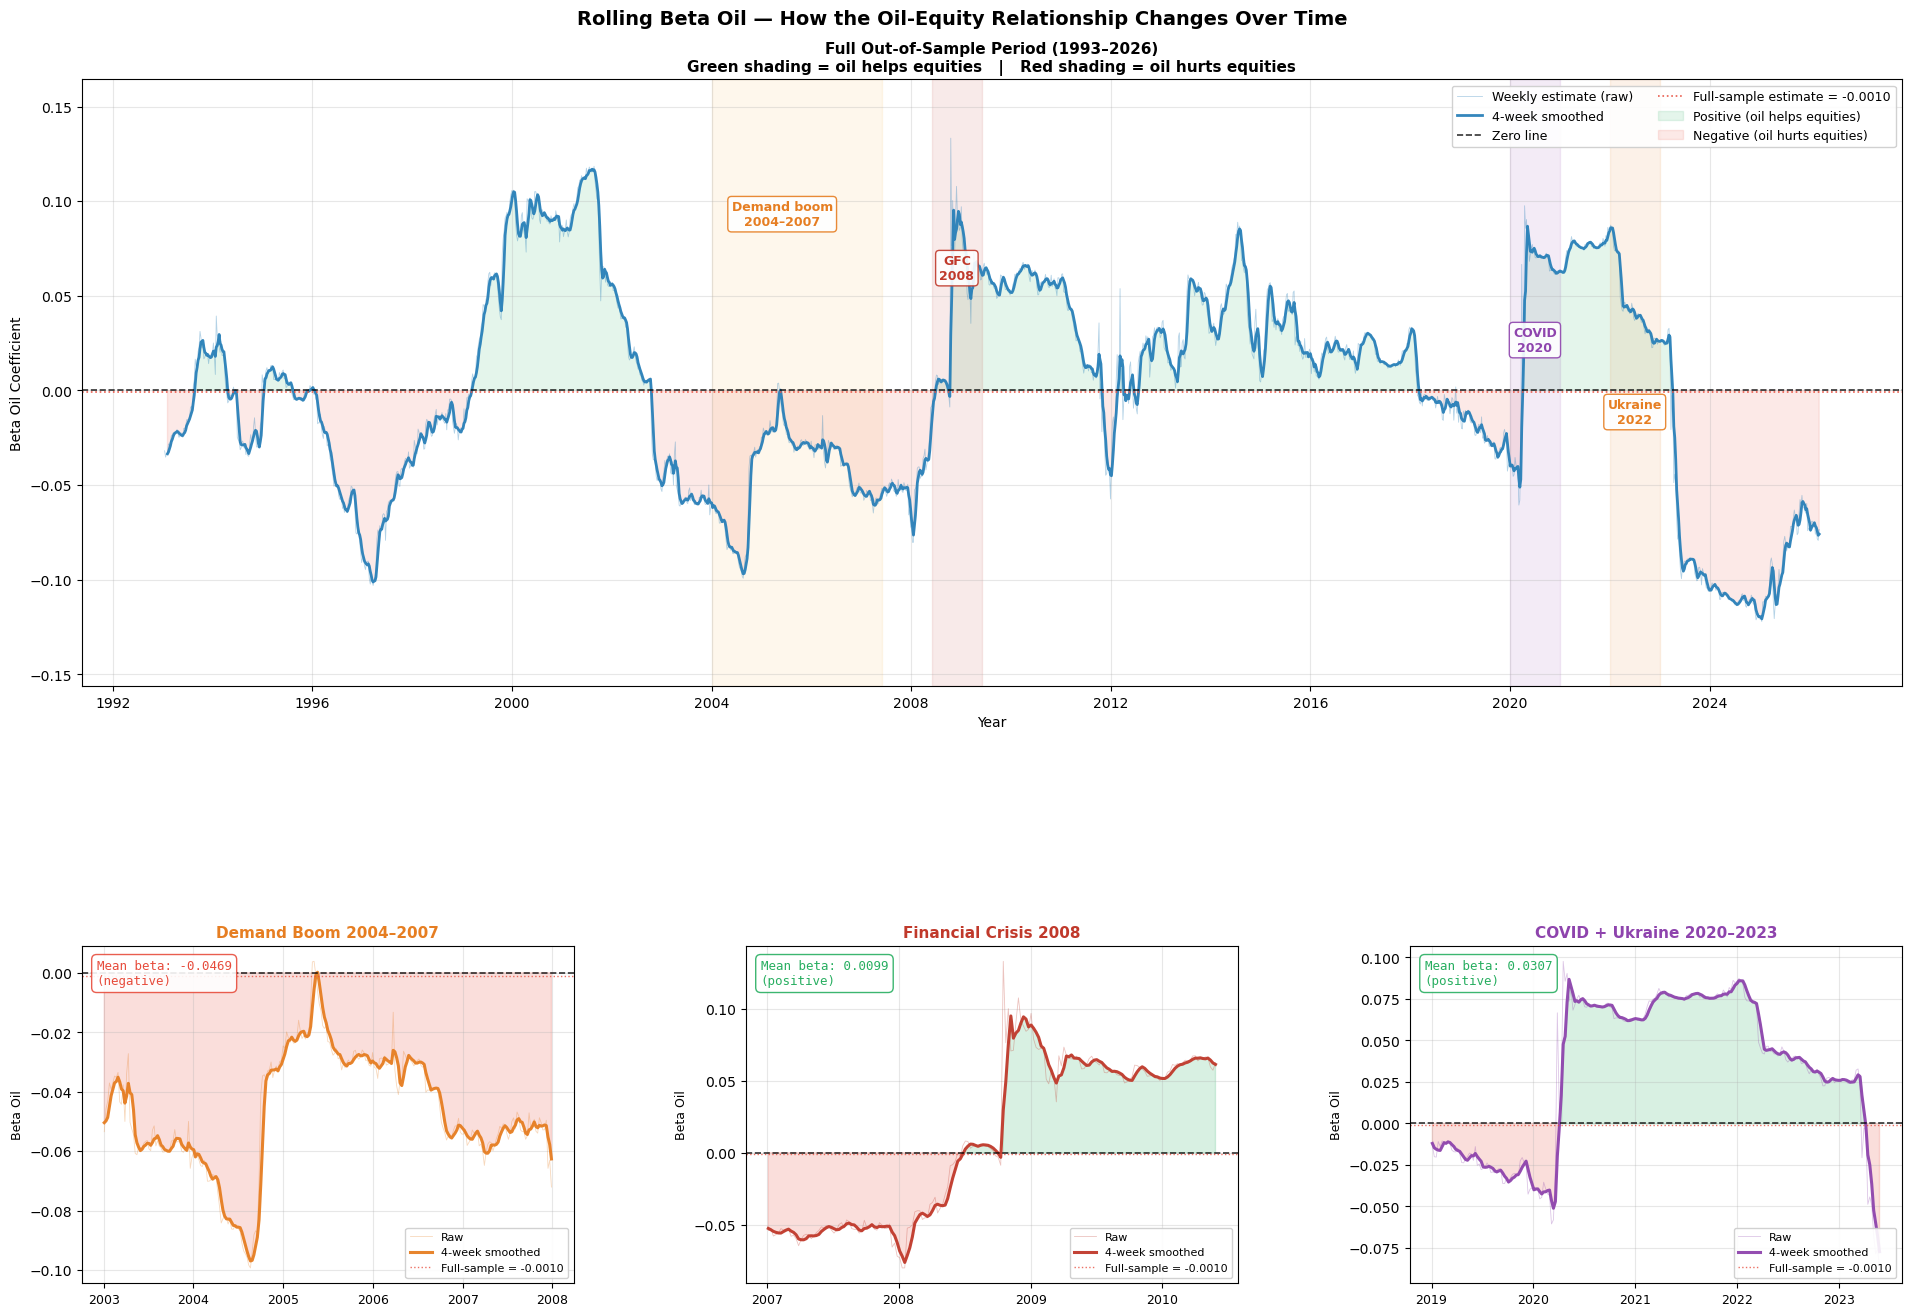

Rolling Beta Oil — Regime Averages

Full sample (1993-01-15 → 2026-03-13):
  Mean beta_oil : 0.00067  (positive)

Demand boom (2004-01-01 → 2007-06-01):
  Mean beta_oil : -0.04423  (negative)

GFC 2008 (2008-06-01 → 2009-06-01):
  Mean beta_oil : 0.04748  (positive)

Post-GFC calm (2010-01-01 → 2019-12-31):
  Mean beta_oil : 0.02101  (positive)

COVID 2020 (2020-01-01 → 2020-12-31):
  Mean beta_oil : 0.04230  (positive)

Ukraine 2022 (2022-01-01 → 2022-12-31):
  Mean beta_oil : 0.04387  (positive)


In [86]:
rolling_beta_oil_series = pd.Series(rolling_beta_oil, index=dates_arr)
rolling_beta_smooth     = rolling_beta_oil_series.rolling(4).mean()
full_sample_beta_oil    = float(beta_hat[2, 0])

fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1.8, 1])

ax_main   = fig.add_subplot(gs[0, :])
ax_demand = fig.add_subplot(gs[1, 0])
ax_gfc    = fig.add_subplot(gs[1, 1])
ax_recent = fig.add_subplot(gs[1, 2])

fig.suptitle("Rolling Beta Oil — How the Oil-Equity Relationship Changes Over Time",
             fontsize=14, fontweight="bold", y=0.98)

ax_main.plot(rolling_beta_oil_series.index, rolling_beta_oil_series,
             color="#2980b9", linewidth=0.6, alpha=0.35, label="Weekly estimate (raw)")
ax_main.plot(rolling_beta_smooth.index, rolling_beta_smooth,
             color="#2980b9", linewidth=2.0, alpha=0.95, label="4-week smoothed")
ax_main.axhline(0, color="black", linewidth=1.2,
                linestyle="--", alpha=0.8, zorder=2, label="Zero line")
ax_main.axhline(full_sample_beta_oil, color="#e74c3c", linewidth=1.2,
                linestyle=":", alpha=0.9,
                label=f"Full-sample estimate = {full_sample_beta_oil:.4f}")

ymin   = rolling_beta_smooth.dropna().min()
ymax   = rolling_beta_smooth.dropna().max()
yrange = ymax - ymin

ax_main.fill_between(rolling_beta_smooth.index, rolling_beta_smooth, 0,
                     where=(rolling_beta_smooth > 0),
                     alpha=0.12, color="#27ae60", label="Positive (oil helps equities)")
ax_main.fill_between(rolling_beta_smooth.index, rolling_beta_smooth, 0,
                     where=(rolling_beta_smooth < 0),
                     alpha=0.12, color="#e74c3c", label="Negative (oil hurts equities)")

crises_main = [
    ("2008-06-01", "2009-06-01", "#c0392b", "GFC\n2008",     0.78),
    ("2020-01-01", "2020-12-31", "#8e44ad", "COVID\n2020",   0.62),
    ("2022-01-01", "2022-12-31", "#e67e22", "Ukraine\n2022", 0.46),
]

for start, end, color, label, y_frac in crises_main:
    ax_main.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.10, color=color, zorder=1)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax_main.text(mid, ymin + yrange * y_frac, label,
                 color=color, fontsize=9, fontweight="bold",
                 ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.3",
                           facecolor="white", edgecolor=color, alpha=0.9))

ax_main.axvspan(pd.Timestamp("2004-01-01"), pd.Timestamp("2007-06-01"),
                alpha=0.08, color="#f39c12", zorder=1)
ax_main.text(pd.Timestamp("2005-06-01"), ymin + yrange * 0.90,
             "Demand boom\n2004–2007",
             color="#e67e22", fontsize=9, fontweight="bold",
             ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="white", edgecolor="#e67e22", alpha=0.9))

ax_main.set_ylim(ymin - yrange * 0.15, ymax + yrange * 0.20)
ax_main.set_title("Full Out-of-Sample Period (1993–2026)\n"
                  "Green shading = oil helps equities   |   "
                  "Red shading = oil hurts equities",
                  fontsize=11, fontweight="bold")
ax_main.set_xlabel("Year", fontsize=10)
ax_main.set_ylabel("Beta Oil Coefficient", fontsize=10)
ax_main.legend(fontsize=9, loc="upper right", framealpha=0.9, ncol=2)
ax_main.grid(True, alpha=0.3)
ax_main.xaxis.set_major_locator(mdates.YearLocator(4))
ax_main.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_main.tick_params(axis="x", labelsize=10, rotation=0)

zoom_windows = [
    (ax_demand, "Demand Boom 2004–2007",     "2003-01-01", "2008-01-01", "#e67e22"),
    (ax_gfc,    "Financial Crisis 2008",      "2007-01-01", "2010-06-01", "#c0392b"),
    (ax_recent, "COVID + Ukraine 2020–2023",  "2019-01-01", "2023-06-01", "#8e44ad"),
]

for ax, title, start, end, color in zoom_windows:

    mask   = (rolling_beta_smooth.index >= start)     & (rolling_beta_smooth.index <= end)
    mask_r = (rolling_beta_oil_series.index >= start) & (rolling_beta_oil_series.index <= end)

    x_s = rolling_beta_smooth.index[mask]
    y_s = rolling_beta_smooth[mask]
    x_r = rolling_beta_oil_series.index[mask_r]
    y_r = rolling_beta_oil_series[mask_r]

    ax.plot(x_r, y_r, color=color, linewidth=0.6, alpha=0.30, label="Raw")
    ax.plot(x_s, y_s, color=color, linewidth=2.2, alpha=0.95, label="4-week smoothed")

    ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.8)
    ax.axhline(full_sample_beta_oil, color="#e74c3c", linewidth=1.0,
               linestyle=":", alpha=0.8,
               label=f"Full-sample = {full_sample_beta_oil:.4f}")

    ax.fill_between(x_s, y_s, 0, where=(y_s > 0), alpha=0.18, color="#27ae60")
    ax.fill_between(x_s, y_s, 0, where=(y_s < 0), alpha=0.18, color="#e74c3c")

    mean_b     = y_r.mean()
    sign       = "positive" if mean_b > 0 else "negative"
    sign_color = "#27ae60"  if mean_b > 0 else "#e74c3c"

    ax.text(0.03, 0.96,
            f"Mean beta: {mean_b:.4f}\n({sign})",
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            fontfamily="monospace", color=sign_color,
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white", edgecolor=sign_color, alpha=0.9))

    ax.set_title(title, fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("", fontsize=9)
    ax.set_ylabel("Beta Oil", fontsize=9)
    ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelsize=9, rotation=0)

plt.subplots_adjust(top=0.93, bottom=0.07, left=0.06,
                    right=0.97, hspace=0.55, wspace=0.35)
plt.show()

print("=" * 60)
print("Rolling Beta Oil — Regime Averages")
print("=" * 60)

regimes = [
    ("Full sample",   str(dates_arr[0].date()), str(dates_arr[-1].date())),
    ("Demand boom",   "2004-01-01",              "2007-06-01"),
    ("GFC 2008",      "2008-06-01",              "2009-06-01"),
    ("Post-GFC calm", "2010-01-01",              "2019-12-31"),
    ("COVID 2020",    "2020-01-01",              "2020-12-31"),
    ("Ukraine 2022",  "2022-01-01",              "2022-12-31"),
]

for name, start, end in regimes:
    mask = (rolling_beta_oil_series.index >= start) & (rolling_beta_oil_series.index <= end)
    if mask.sum() == 0:
        continue
    mean_b = rolling_beta_oil_series[mask].mean()
    sign   = "positive" if mean_b > 0 else "negative"
    print(f"\n{name} ({start} → {end}):")
    print(f"  Mean beta_oil : {mean_b:.5f}  ({sign})")

The main chart shows the full history of the rolling $\hat{\beta}_{oil}$ from 1993 to 2026. The three bottom panels zoom in on the demand boom, the GFC and the recent crisis episodes. Mean beta values by regime are printed below the charts.